<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/MPGPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Data and Data Cleaning

In [ ]:
MPGData <- read.csv("/content/2025MPGData.csv")
head(MPGData)

,Model.Year,Mfr.Name,Division,Carline,Verify.Mfr.Cd,Index..Model.Type.Index.,Eng.Displ,X..Cyl,Transmission,City.FE..Guide....Conventional.Fuel,⋯,X120V.Charge.time.at.120.Volts..hours.,PHEV.Total.Driving.Range..rounded.to.nearest.10.miles.DISTANCE,City.PHEV.Composite.MPGe,Hwy.PHEV.Composite.MPGe,Comb.PHEV.Composite.MPGe,X,X.1,X.2,X.3,X.4
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<chr>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,2025,Honda,Acura,ADX AWD,HNX,581,1.5,4,Auto(AV-S7),25,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,2025,Honda,Acura,ADX FWD,HNX,582,1.5,4,Auto(AV-S7),26,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,2025,Honda,Acura,INTEGRA,HNX,541,1.5,4,Auto(AV-S7),30,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,2025,Honda,Acura,INTEGRA,HNX,544,2.0,4,Manual(M6),21,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,2025,Honda,Acura,INTEGRA A-SPEC,HNX,542,1.5,4,Auto(AV-S7),29,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,2025,Honda,Acura,INTEGRA A-SPEC,HNX,543,1.5,4,Manual(M6),26,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [ ]:
print(colSums(is.na(MPGData)))

                                                                                              Model.Year 
                                                                                                       0 
                                                                                                Mfr.Name 
                                                                                                       0 
                                                                                                Division 
                                                                                                       0 
                                                                                                 Carline 
                                                                                                       0 
                                                                                           Verify.Mfr.Cd 
                                              

In [ ]:
# Get columns with more than 400 NA values
na_counts <- colSums(is.na(MPGData))
columns_to_drop <- names(na_counts[na_counts > 400])

# Drop these columns from the DataFrame
MPGData_cleaned <- MPGData[, !(names(MPGData) %in% columns_to_drop)]

# Display the dimensions of the new dataframe to confirm columns were dropped
print(dim(MPGData))
print(dim(MPGData_cleaned))

# Display null counts for the cleaned data to verify
print(colSums(is.na(MPGData_cleaned)))

[1] 868 167
[1] 868  95
                                                                                              Model.Year 
                                                                                                       0 
                                                                                                Mfr.Name 
                                                                                                       0 
                                                                                                Division 
                                                                                                       0 
                                                                                                 Carline 
                                                                                                       0 
                                                                                           Verify.Mfr.Cd 
                      

In [ ]:
names(MPGData_cleaned)

[1] "Model.Year"                                                                                              
 [2] "Mfr.Name"                                                                                                
 [3] "Division"                                                                                                
 [4] "Carline"                                                                                                 
 [5] "Verify.Mfr.Cd"                                                                                           
 [6] "Index..Model.Type.Index."                                                                                
 [7] "Eng.Displ"                                                                                               
 [8] "X..Cyl"                                                                                                  
 [9] "Transmission"                                                                                            
[10] "City.FE..Guide....Conventional.Fuel"                                                                     
[11] "Hwy.FE..Guide....Conventional.Fuel"                                                                      
[12] "Comb.FE..Guide....Conventional.Fuel"                                                                     
[13] "City.Unadj.FE...Conventional.Fuel"                                                                       
[14] "Hwy.Unadj.FE...Conventional.Fuel"                                                                        
[15] "Comb.Unadj.FE...Conventional.Fuel"                                                                       
[16] "City.Unrd.Adj.FE...Conventional.Fuel"                                                                    
[17] "Hwy.Unrd.Adj.FE...Conventional.Fuel"                                                                     
[18] "Comb.Unrd.Adj.FE...Conventional.Fuel"                                                                    
[19] "Guzzler."                                                                                                
[20] "Air.Aspir.Method"                                                                                        
[21] "Air.Aspiration.Method.Desc"                                                                              
[22] "Trans"                                                                                                   
[23] "Trans.Desc"                                                                                              
[24] "X..Gears"                                                                                                
[25] "Lockup.Torque.Converter"                                                                                 
[26] "Trans.Creeper.Gear"                                                                                      
[27] "Drive.Sys"                                                                                               
[28] "Drive.Desc"                                                                                              
[29] "Max.Ethanol.....Gasoline"                                                                                
[30] "Range1...Model.Type.Driving.Range...Conventional.Fuel"                                                   
[31] "Fuel.Usage....Conventional.Fuel"                                                                         
[32] "Fuel.Usage.Desc...Conventional.Fuel"                                                                     
[33] "Fuel.Unit...Conventional.Fuel"                                                                           
[34] "Fuel.Unit.Desc...Conventional.Fuel"                                                                      
[35] "Gas.Guzzler.Exempt..Where.Truck...1975.NHTSA.truck.definition."                                          
[36] "Gas.Guzzler.Exempt.Desc..Where.Truck...1975.NHTSA.truck.definition."       

In [ ]:
names(MPGData_cleaned)[names(MPGData_cleaned) ==
"City.FE..Guide....Conventional.Fuel"] <- "MPG"

names(MPGData_cleaned)[names(MPGData_cleaned) ==
"X..Cyl"] <- "Cylinders"
MPGData_cleaned$Cylinders <- as.factor(MPGData_cleaned$Cylinders)

names(MPGData_cleaned)[names(MPGData_cleaned) ==
"City.CO2.Rounded.Adjusted"] <- "CO2"

names(MPGData_cleaned)[names(MPGData_cleaned) ==
"Drive.Sys"] <- "Drive"
MPGData_cleaned$Drive <- as.factor(MPGData_cleaned$Drive)

names(MPGData_cleaned)[names(MPGData_cleaned) ==
"Transmission"] <- "Transmission"

names(MPGData_cleaned)[names(MPGData_cleaned) ==
"Stop.Start.System..Engine.Management.System..Code"] <- "StartStop"
MPGData_cleaned$StartStop <- as.factor(MPGData_cleaned$StartStop)

names(MPGData_cleaned)[names(MPGData_cleaned) ==
"X.1.Mfr.Smog.Rating..Mfr.Smog.1.10.Rating.on.Label.for.Test.Group.1."] <- "Smog"

names(MPGData_cleaned)[names(MPGData_cleaned) ==
"X..Gears"] <- "Gears"

names(MPGData_cleaned)[names(MPGData_cleaned) ==
"Eng.Displ"] <- "Displacement"

In [ ]:
attach(MPGData_cleaned)

The following objects are masked from MPGData_cleaned (pos = 3):

    Air.Aspir.Method, Air.Aspiration.Method.Desc,
    Annual.Fuel1.Cost...Conventional.Fuel, Batt.Charger.Type.Desc,
    Battery.Type..If.Other, Battery.Type.Desc, Calc.Approach.Desc,
    Camless.Valvetrain..Y.or.N.,
    Car.Truck.Category...Cash.for.Clunkers.Bill., Carline,
    Carline.Class, Carline.Class.Desc,
    City.Unadj.FE...Conventional.Fuel,
    City.Unrd.Adj.FE...Conventional.Fuel, CO2,
    Comb.CO2.Rounded.Adjusted..as.shown.on.FE.Label.,
    Comb.FE..Guide....Conventional.Fuel,
    Comb.Unadj.FE...Conventional.Fuel,
    Comb.Unrd.Adj.FE...Conventional.Fuel, Comments...Mfr.Eng.Cnfg,
    Cyl.Deact., Cyl.Deact.Desc, Cylinders,
    Descriptor...Model.Type..40.Char.or.less., Displacement, Division,
    Drive, Drive.Desc, Driver.Cntrl.Regen.Braking.,
    Energy.Storage.Device.Desc,
    EPA.Calculated.Annual.Fuel.Cost...Conventional.Fuel........Annual.fuel.cost.error..Please.revise.Verify.,
    EPA.FE.Label.Dataset

In [ ]:
print(unique(MPGData_cleaned$Transmission))

MPGData_cleaned$TransmissionType <- ifelse(grepl("Manual", MPGData_cleaned$Transmission), "M", "A")
MPGData_cleaned$TransmissionType <- as.factor(MPGData_cleaned$TransmissionType)
print(table(MPGData_cleaned$TransmissionType))

 [1] "Auto(AV-S7)"  "Manual(M6)"   "Auto(S10)"    "Auto(A8)"     "Auto(A9)"    
 [6] "Auto(AM-S7)"  "Auto(S8)"     "Auto(AV)"     "Auto(S9)"     "Auto(A6)"    
[11] "Auto(A10)"    "Auto(AM8)"    "Auto(AM7)"    "Manual(M7)"   "Auto(AM-S8)" 
[16] "Auto(AV-S1)"  "Auto(AM-S6)"  "Auto(AV-S8)"  "Auto(AV-S6)"  "Auto(S6)"    
[21] "Auto(AV-S10)" "Manual(M5)"  

  A   M 
830  38 


# Investigating Variables

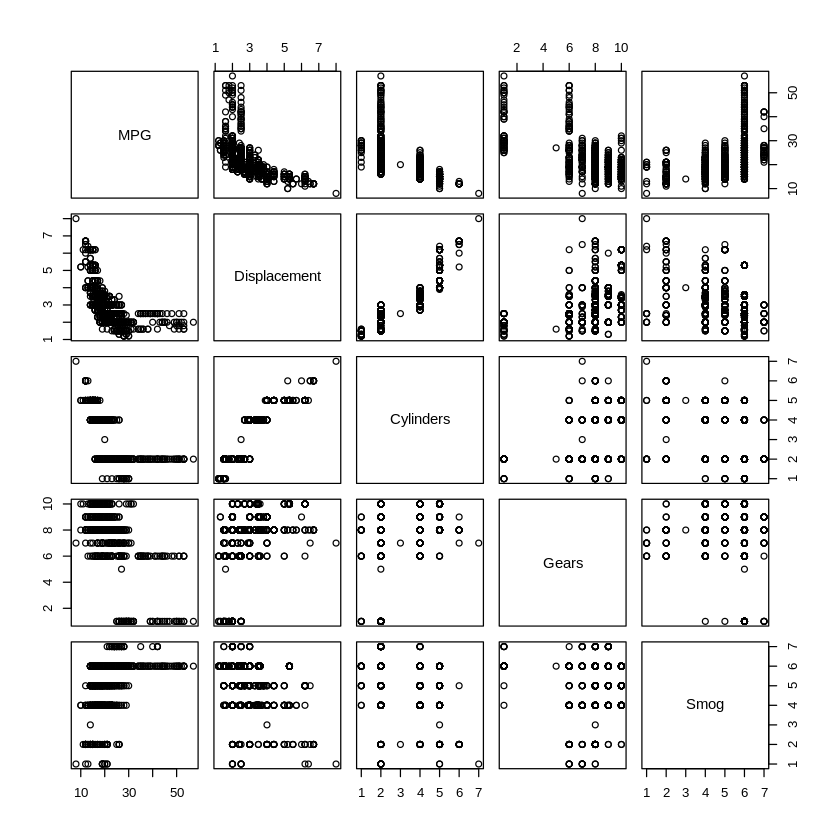

In [ ]:
plot_data <- MPGData_cleaned[, c("MPG", "Displacement", "Cylinders", "Gears", "Smog")]

pairs(plot_data)

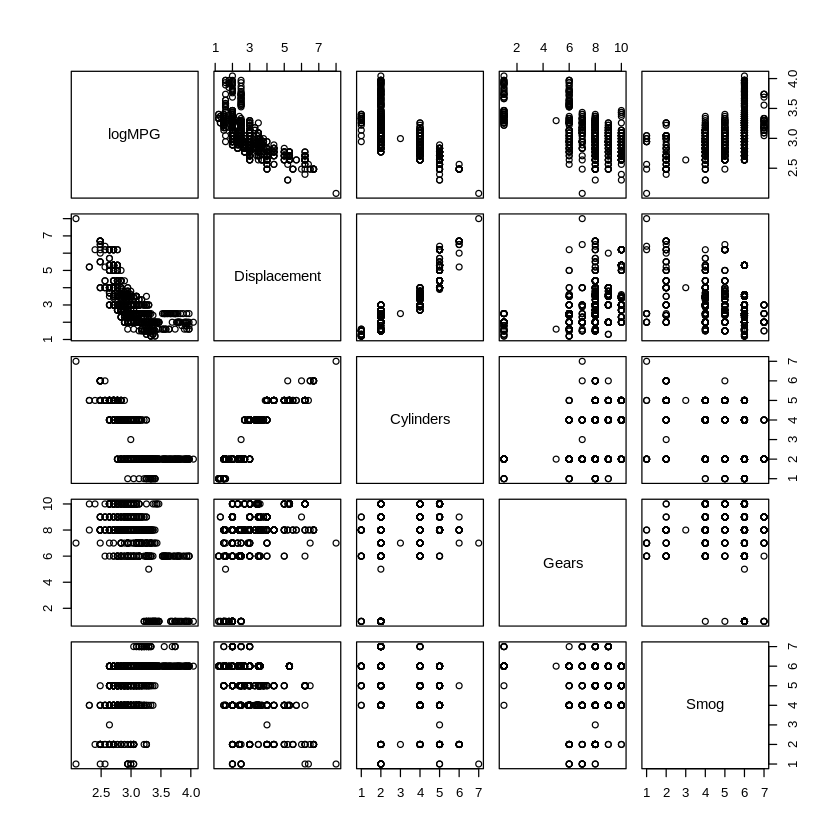

In [ ]:
MPGData_cleaned$logMPG <- log(MPGData_cleaned$MPG)

plot_data <- MPGData_cleaned[, c("logMPG", "Displacement", "Cylinders", "Gears", "Smog")]

pairs(plot_data)

## Displacement (Variable we think is most important)

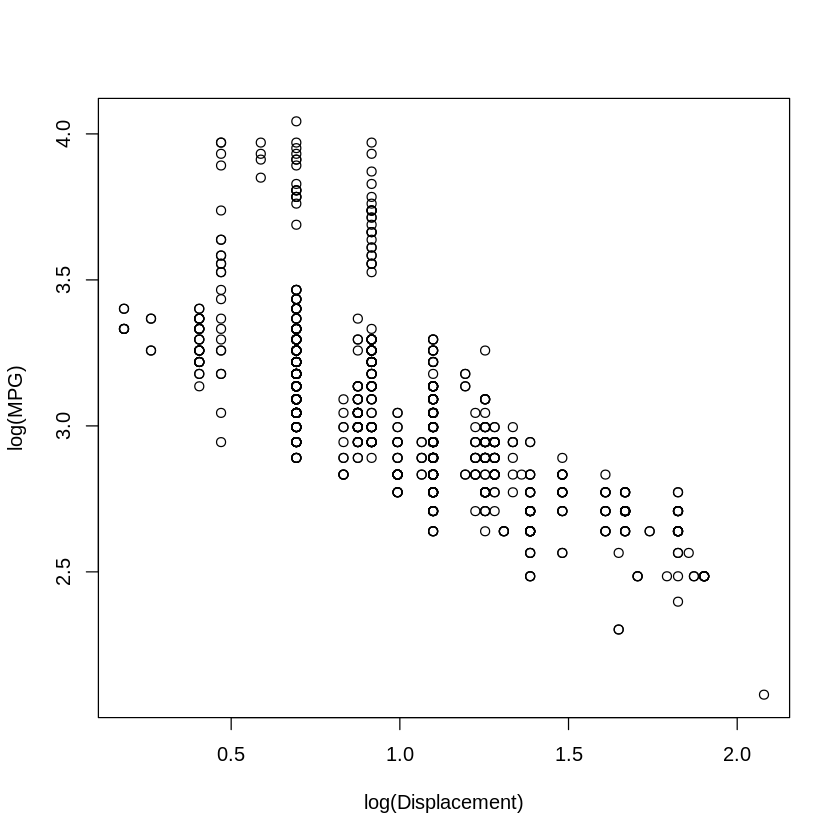

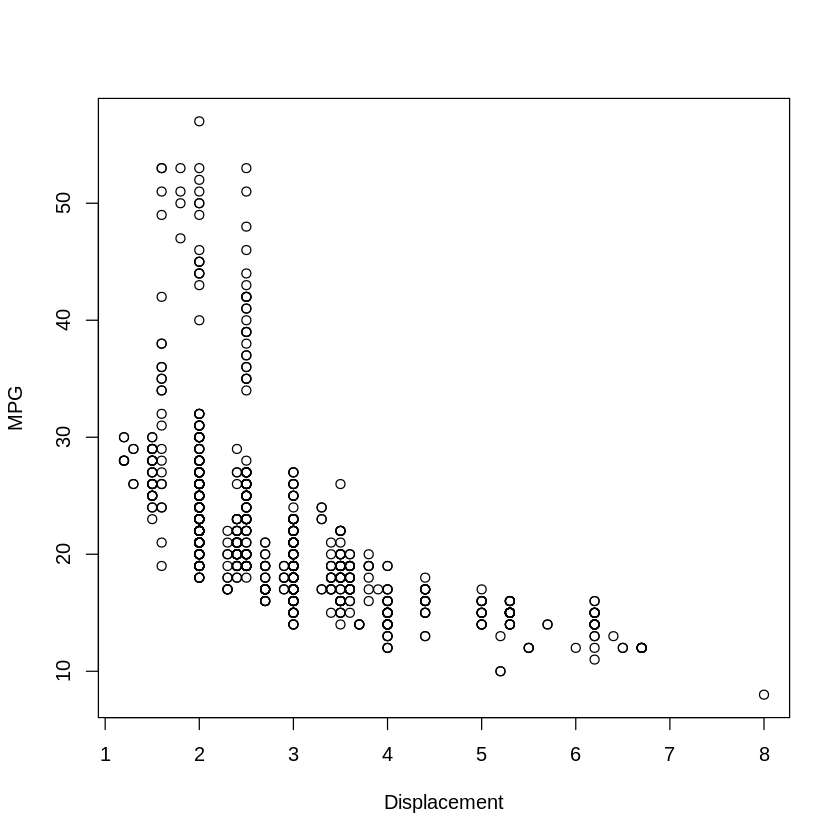

In [ ]:
plot(log(Displacement), log(MPG))
plot(Displacement, MPG)

In [ ]:
displacementLm <- lm(MPG~Displacement, data = MPGData_cleaned)
logdisplacementLm <- lm(log(MPG)~log(Displacement), data = MPGData_cleaned)
summary(logdisplacementLm)
summary(displacementLm)


Call:
lm(formula = log(MPG) ~ log(Displacement), data = MPGData_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.41050 -0.13214 -0.03934  0.08392  0.87886 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.63246    0.02072  175.32   <2e-16 ***
log(Displacement) -0.59046    0.01922  -30.72   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2045 on 866 degrees of freedom
Multiple R-squared:  0.5215,	Adjusted R-squared:  0.521 
F-statistic: 943.9 on 1 and 866 DF,  p-value: < 2.2e-16



Call:
lm(formula = MPG ~ Displacement, data = MPGData_cleaned)

Residuals:
   Min     1Q Median     3Q    Max 
-7.810 -3.593 -1.320  1.680 31.680 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   32.7737     0.5540   59.16   <2e-16 ***
Displacement  -3.7270     0.1742  -21.39   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.007 on 866 degrees of freedom
Multiple R-squared:  0.3457,	Adjusted R-squared:  0.345 
F-statistic: 457.6 on 1 and 866 DF,  p-value: < 2.2e-16


## Cylinders only

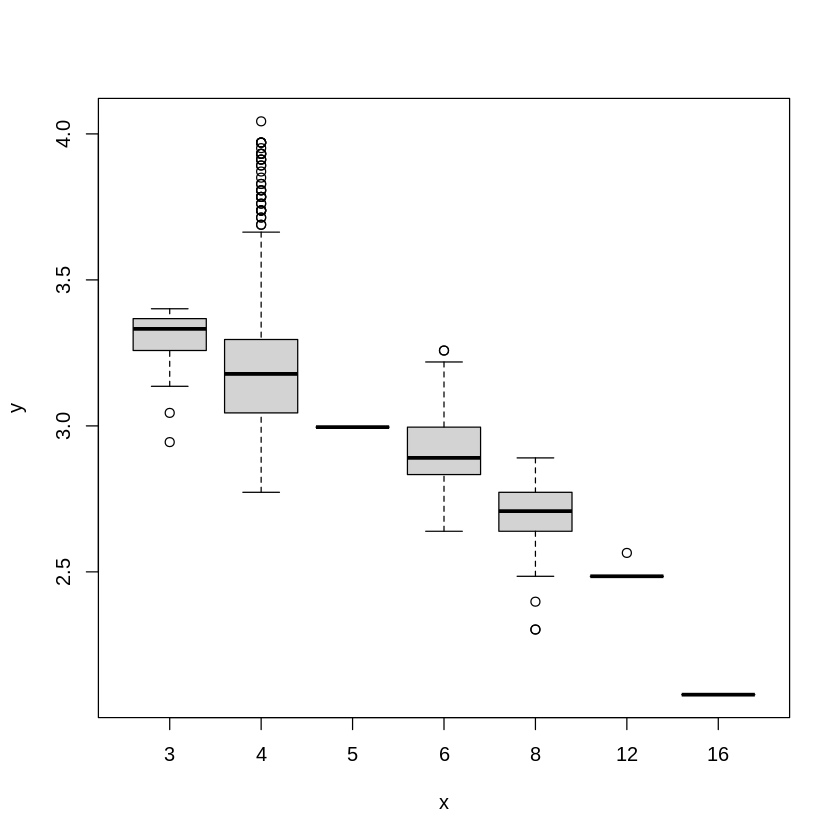

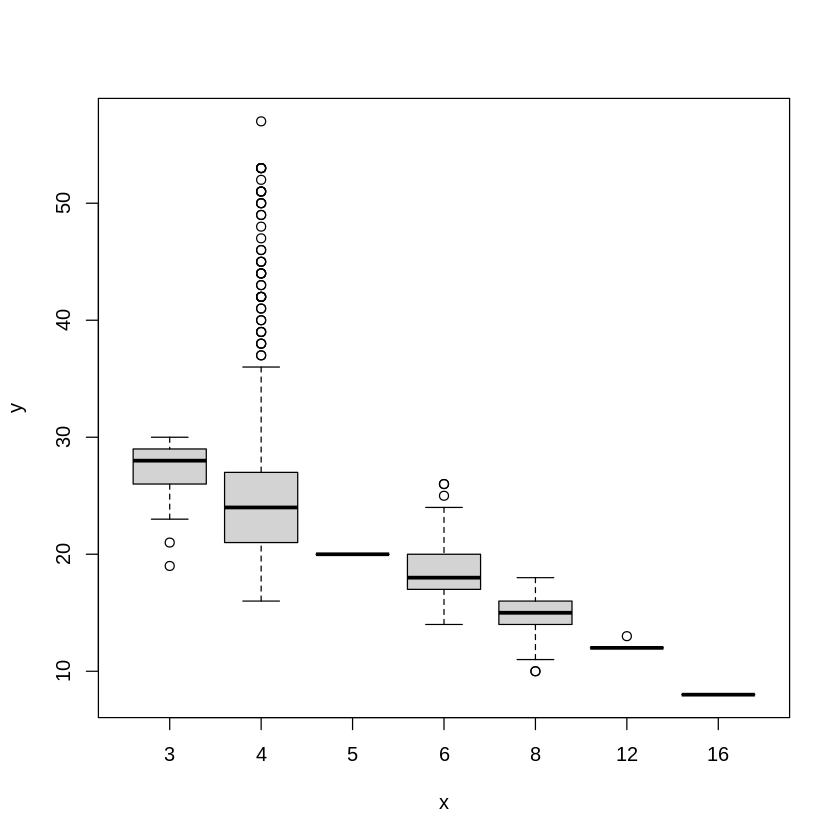

In [ ]:
plot(Cylinders, log(MPG))
plot(Cylinders, MPG)

In [ ]:
logcylindersLm <- lm(log(MPG)~Cylinders)
cylindersLm <- lm(MPG~Cylinders)
summary(logcylindersLm)
summary(cylindersLm)


Call:
lm(formula = log(MPG) ~ Cylinders)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.43979 -0.12134 -0.00728  0.08345  0.83067 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.28610    0.04473  73.458  < 2e-16 ***
Cylinders4  -0.07371    0.04578  -1.610    0.108    
Cylinders5  -0.29036    0.20982  -1.384    0.167    
Cylinders6  -0.37707    0.04650  -8.109 1.74e-15 ***
Cylinders8  -0.60076    0.04819 -12.467  < 2e-16 ***
Cylinders12 -0.79391    0.07630 -10.405  < 2e-16 ***
Cylinders16 -1.20665    0.20982  -5.751 1.23e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.205 on 861 degrees of freedom
Multiple R-squared:  0.5222,	Adjusted R-squared:  0.5188 
F-statistic: 156.8 on 6 and 861 DF,  p-value: < 2.2e-16



Call:
lm(formula = MPG ~ Cylinders)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.7941 -2.7941 -0.4904  1.2059 31.2059 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   26.905      1.278  21.052  < 2e-16 ***
Cylinders4    -1.111      1.308  -0.849  0.39606    
Cylinders5    -6.905      5.994  -1.152  0.24969    
Cylinders6    -8.414      1.328  -6.334 3.84e-10 ***
Cylinders8   -12.172      1.377  -8.842  < 2e-16 ***
Cylinders12  -14.814      2.180  -6.796 2.01e-11 ***
Cylinders16  -18.905      5.994  -3.154  0.00167 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.857 on 861 degrees of freedom
Multiple R-squared:  0.3817,	Adjusted R-squared:  0.3774 
F-statistic: 88.58 on 6 and 861 DF,  p-value: < 2.2e-16


## Drive only

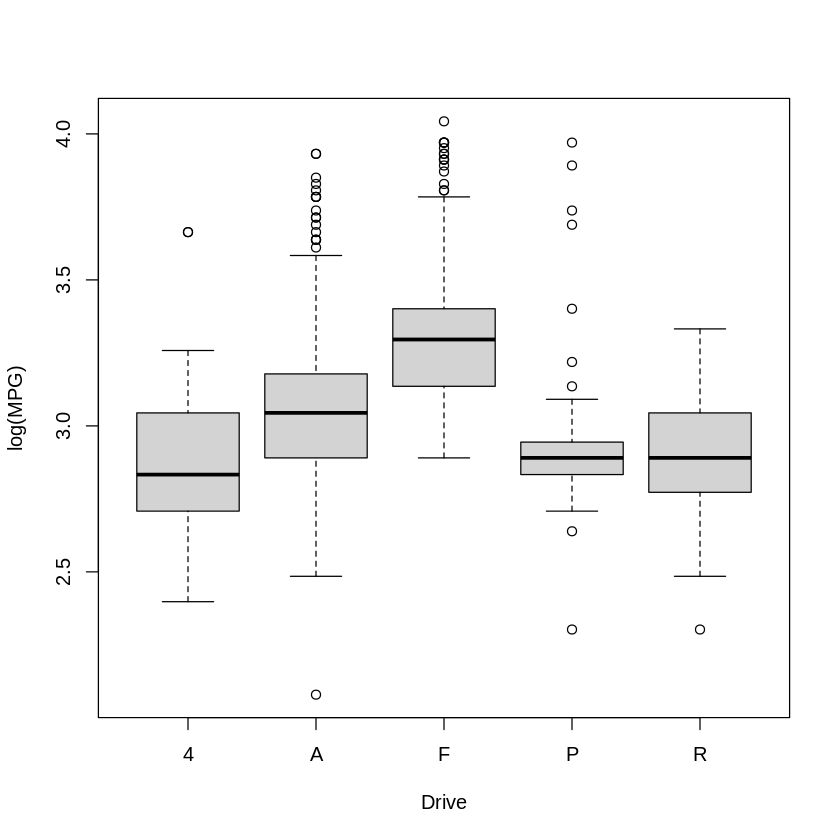

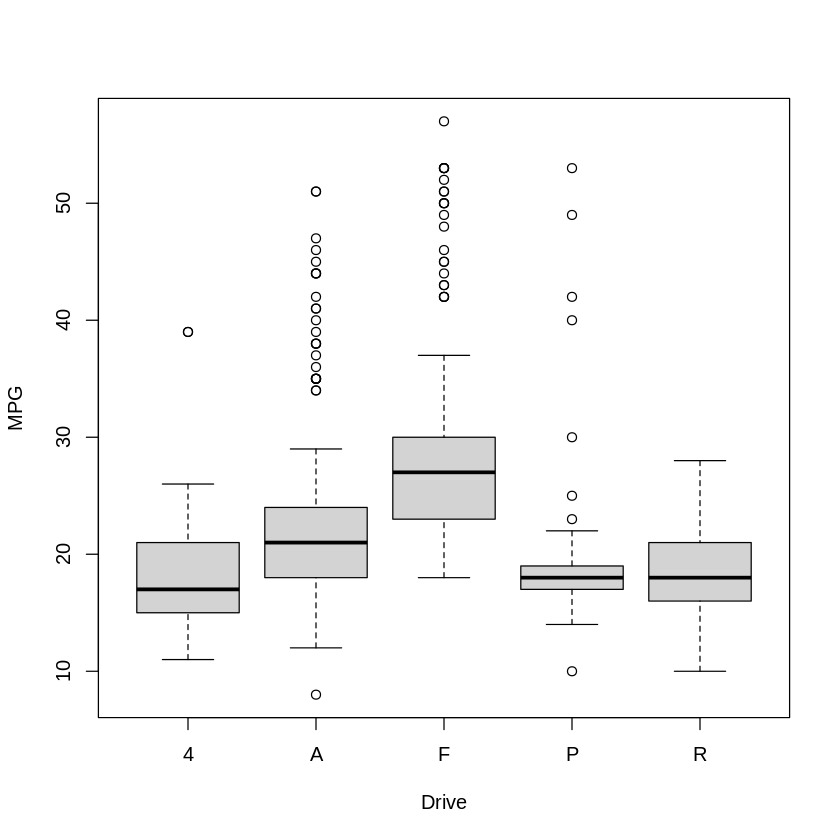

In [ ]:
boxplot(log(MPG)~Drive)
boxplot(MPG~Drive)

In [ ]:
logdriveLm <- lm(log(MPG)~Drive)
driveLm <- lm(MPG~Drive)
summary(logdriveLm)
summary(driveLm)


Call:
lm(formula = log(MPG) ~ Drive)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.95345 -0.17263 -0.01495  0.13708  1.01090 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.88068    0.02147 134.160  < 2e-16 ***
DriveA       0.15221    0.02538   5.998 2.93e-09 ***
DriveF       0.44798    0.02953  15.169  < 2e-16 ***
DriveP       0.07872    0.04217   1.867   0.0623 .  
DriveR       0.02399    0.02903   0.826   0.4088    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2541 on 863 degrees of freedom
Multiple R-squared:  0.2644,	Adjusted R-squared:  0.261 
F-statistic: 77.55 on 4 and 863 DF,  p-value: < 2.2e-16



Call:
lm(formula = MPG ~ Drive)

Residuals:
    Min      1Q  Median      3Q     Max 
-13.592  -3.592  -1.250   2.361  32.612 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  18.2500     0.5459  33.433  < 2e-16 ***
DriveA        3.3421     0.6451   5.181 2.75e-07 ***
DriveF       10.7755     0.7508  14.352  < 2e-16 ***
DriveP        2.1378     1.0720   1.994   0.0465 *  
DriveR        0.3891     0.7381   0.527   0.5983    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.459 on 863 degrees of freedom
Multiple R-squared:  0.2462,	Adjusted R-squared:  0.2427 
F-statistic: 70.48 on 4 and 863 DF,  p-value: < 2.2e-16


## Transmission Type only

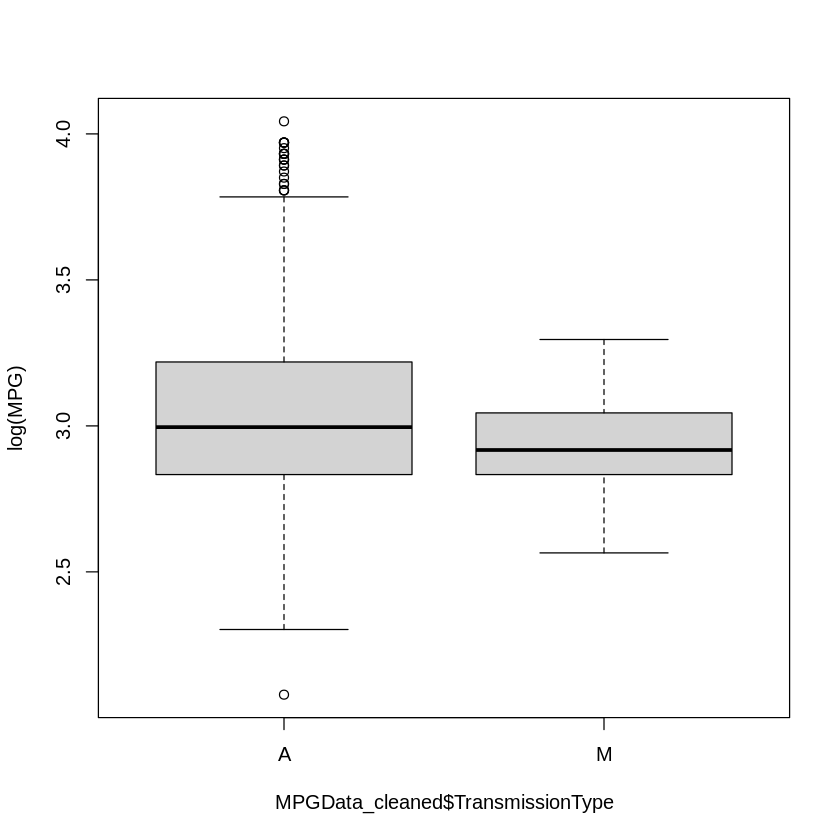

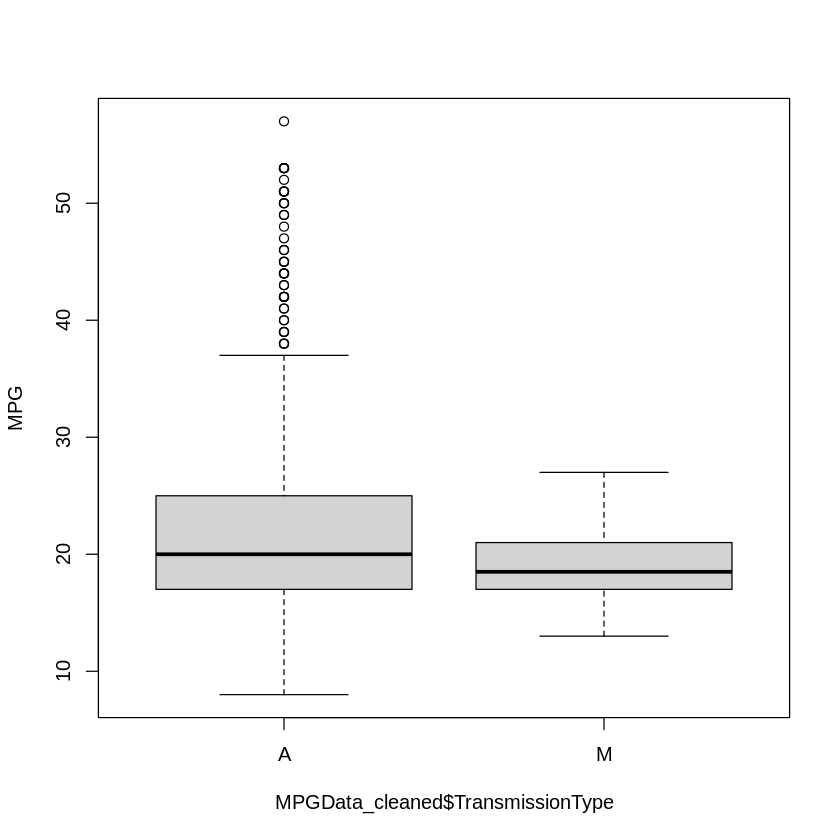

In [ ]:
boxplot(log(MPG)~MPGData_cleaned$TransmissionType)
boxplot(MPG~MPGData_cleaned$TransmissionType)

In [ ]:
logtransmissionLm <- lm(log(MPG)~MPGData_cleaned$TransmissionType)
transmissionLm <- lm(MPG~MPGData_cleaned$TransmissionType)
summary(logtransmissionLm)
summary(transmissionLm)


Call:
lm(formula = log(MPG) ~ MPGData_cleaned$TransmissionType)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.95774 -0.20397 -0.04145  0.18169  1.00587 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        3.03718    0.01024 296.644   <2e-16 ***
MPGData_cleaned$TransmissionTypeM -0.10191    0.04893  -2.083   0.0376 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.295 on 866 degrees of freedom
Multiple R-squared:  0.004984,	Adjusted R-squared:  0.003835 
F-statistic: 4.337 on 1 and 866 DF,  p-value: 0.03758



Call:
lm(formula = MPG ~ MPGData_cleaned$TransmissionType)

Residuals:
    Min      1Q  Median      3Q     Max 
-13.873  -4.873  -1.873   3.127  35.127 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                         21.873      0.257   85.09   <2e-16 ***
MPGData_cleaned$TransmissionTypeM   -2.716      1.228   -2.21   0.0273 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.406 on 866 degrees of freedom
Multiple R-squared:  0.005611,	Adjusted R-squared:  0.004462 
F-statistic: 4.886 on 1 and 866 DF,  p-value: 0.02733


## Start/Stop only

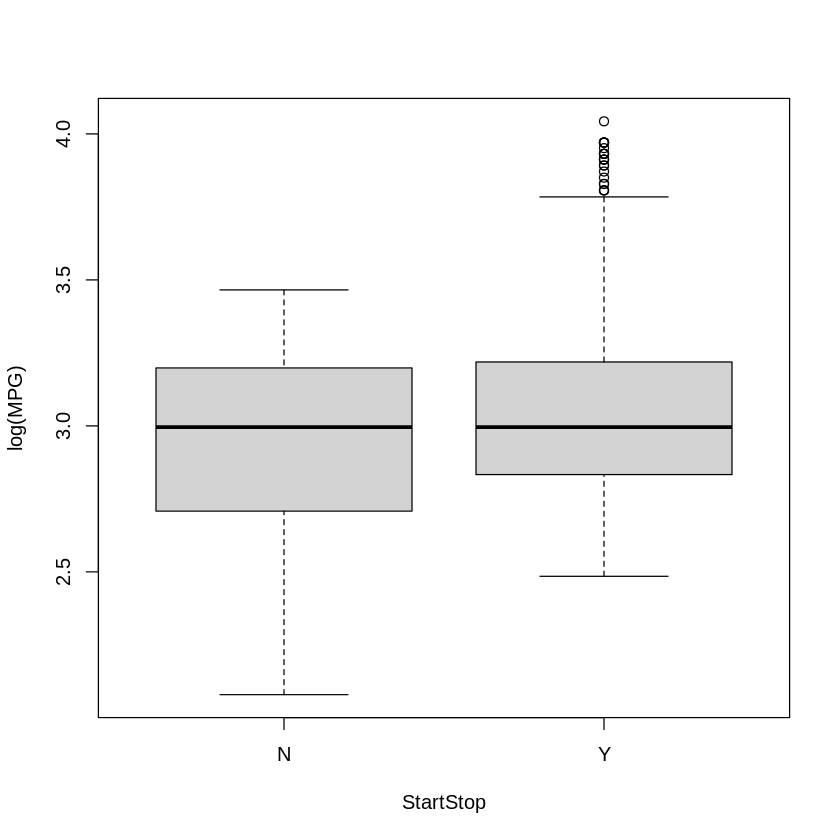

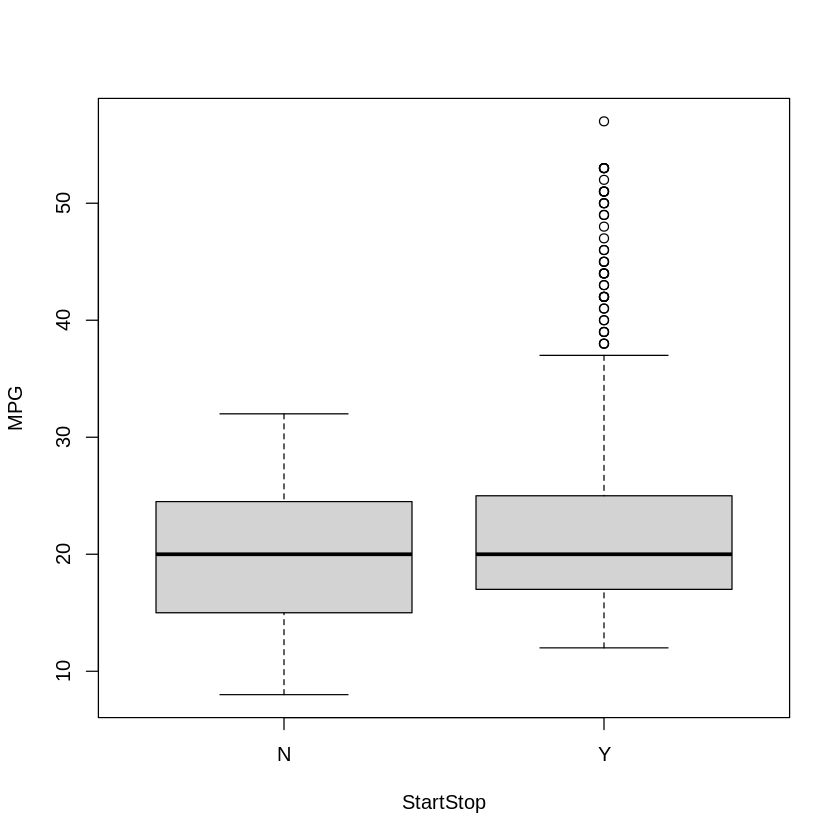

In [ ]:
boxplot(log(MPG)~StartStop)
boxplot(MPG~StartStop)

In [ ]:
logstartStopLm <- lm(log(MPG)~StartStop)
startStopLm <- lm(MPG~StartStop)
summary(logstartStopLm)
summary(startStopLm)


Call:
lm(formula = log(MPG) ~ StartStop)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.88696 -0.21450 -0.02196  0.17116  0.99534 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.96640    0.02324 127.620  < 2e-16 ***
StartStopY   0.08131    0.02574   3.159  0.00164 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.294 on 866 degrees of freedom
Multiple R-squared:  0.01139,	Adjusted R-squared:  0.01025 
F-statistic: 9.981 on 1 and 866 DF,  p-value: 0.001636



Call:
lm(formula = MPG ~ StartStop)

Residuals:
    Min      1Q  Median      3Q     Max 
-12.188  -5.109  -1.188   2.891  34.891 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  20.1875     0.5841   34.56  < 2e-16 ***
StartStopY    1.9213     0.6468    2.97  0.00306 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.389 on 866 degrees of freedom
Multiple R-squared:  0.01009,	Adjusted R-squared:  0.008943 
F-statistic: 8.824 on 1 and 866 DF,  p-value: 0.003055


## CO2 only

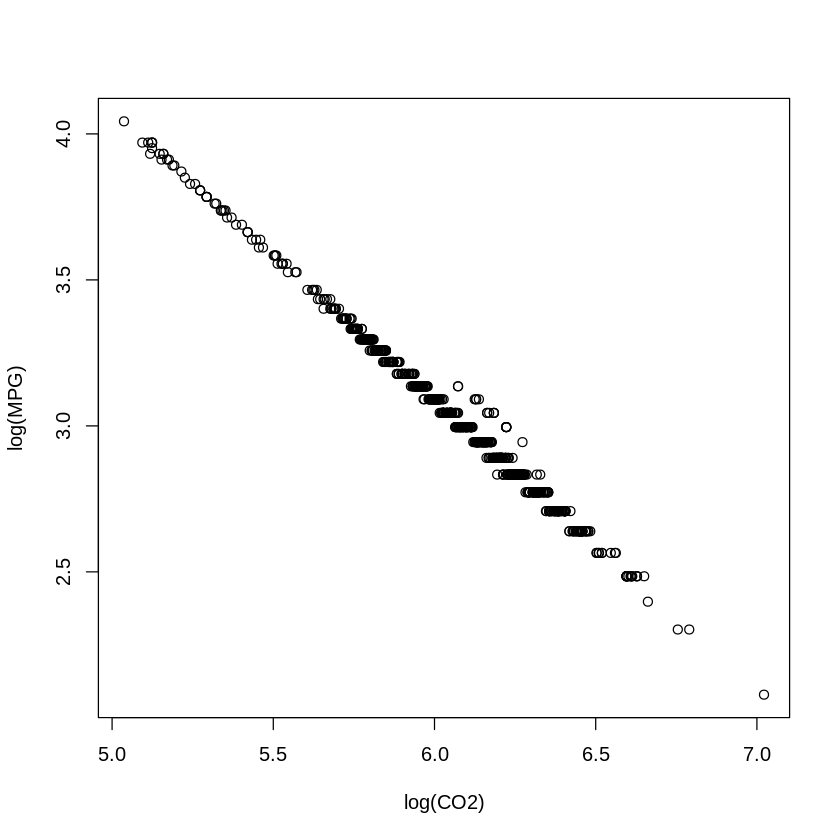

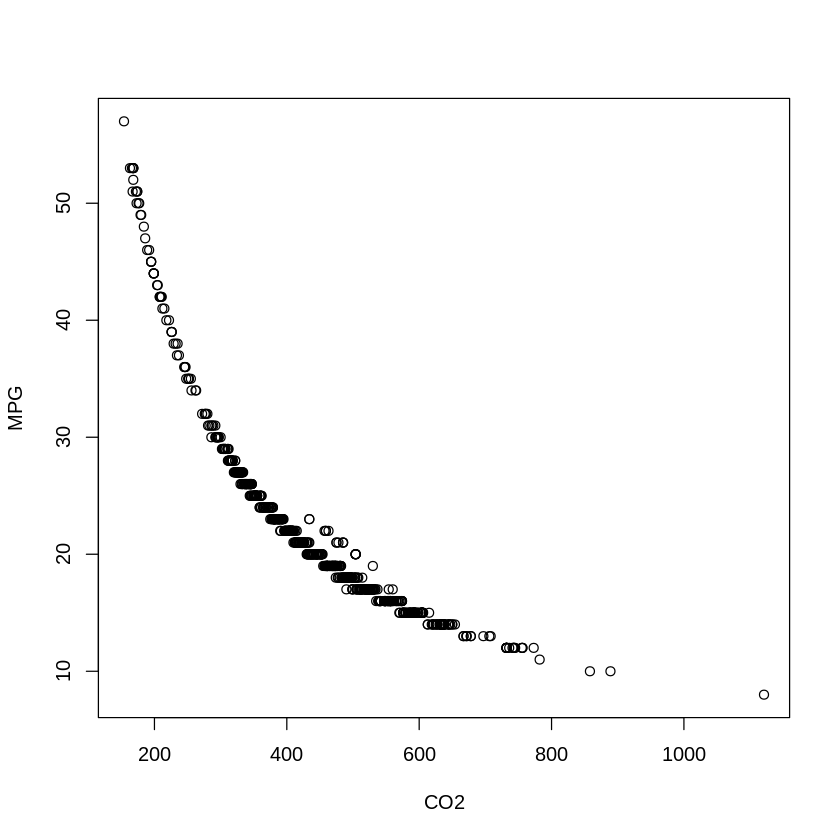

In [ ]:
plot(log(CO2), log(MPG))
plot(CO2, MPG)

In [ ]:
logco2Lm <- lm(log(MPG)~log(CO2))
co2Lm <- lm(MPG~CO2)
summary(logco2Lm)
summary(co2Lm)


Call:
lm(formula = log(MPG) ~ log(CO2))

Residuals:
      Min        1Q    Median        3Q       Max 
-0.065709 -0.012604 -0.001330  0.008548  0.136136 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  9.017531   0.016425   549.0   <2e-16 ***
log(CO2)    -0.987764   0.002708  -364.8   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02378 on 866 degrees of freedom
Multiple R-squared:  0.9935,	Adjusted R-squared:  0.9935 
F-statistic: 1.331e+05 on 1 and 866 DF,  p-value: < 2.2e-16



Call:
lm(formula = MPG ~ CO2)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.7914 -1.8456 -1.1752  0.5444 22.8514 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 45.941465   0.416821  110.22   <2e-16 ***
CO2         -0.054231   0.000901  -60.19   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.262 on 866 degrees of freedom
Multiple R-squared:  0.8071,	Adjusted R-squared:  0.8068 
F-statistic:  3623 on 1 and 866 DF,  p-value: < 2.2e-16


### Why is CO2 directly correlated with MPG?

CO2 is a byproduct of burning fossil fuels. The more fossil fuels you burn, the more carbon dioxide is released. Since these two variables are not independent of each other, we should not include them in our final model.

## Smog only

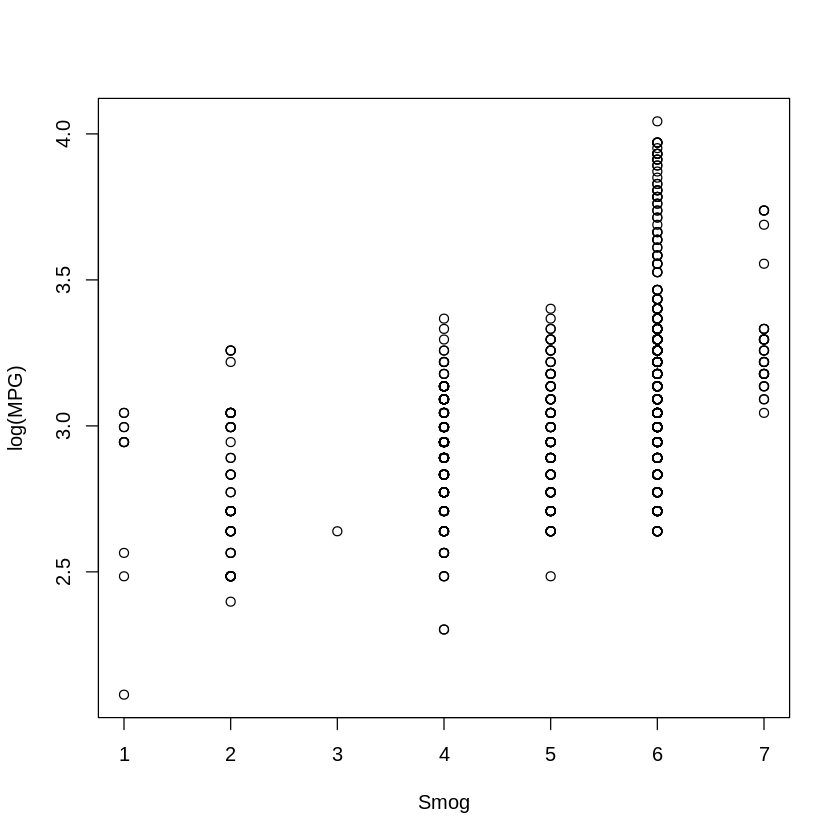

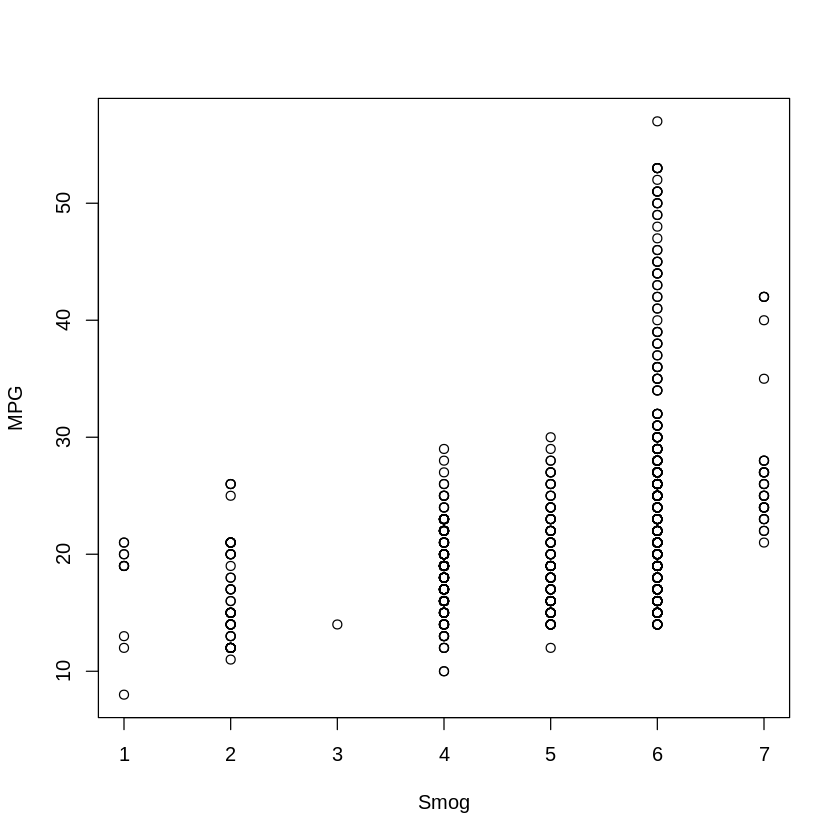

In [ ]:
plot(Smog, log(MPG))
plot(Smog, MPG)

In [ ]:
logsmogLm <- lm(log(MPG)~Smog)
logsmogLm <- lm(MPG~Smog)

summary(logsmogLm)
summary(smogLm)


Call:
lm(formula = MPG ~ Smog)

Residuals:
   Min     1Q Median     3Q    Max 
-10.03  -4.03  -1.03   2.59  32.97 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  10.1710     0.9060   11.23   <2e-16 ***
Smog          2.3098     0.1748   13.22   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.774 on 866 degrees of freedom
Multiple R-squared:  0.1679,	Adjusted R-squared:  0.1669 
F-statistic: 174.7 on 1 and 866 DF,  p-value: < 2.2e-16



Call:
lm(formula = log(MPG) ~ Smog)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.62692 -0.18845 -0.01807  0.16154  0.91016 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.52273    0.03526   71.55   <2e-16 ***
Smog         0.10169    0.00680   14.95   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2636 on 866 degrees of freedom
Multiple R-squared:  0.2052,	Adjusted R-squared:  0.2043 
F-statistic: 223.6 on 1 and 866 DF,  p-value: < 2.2e-16


## Gears only

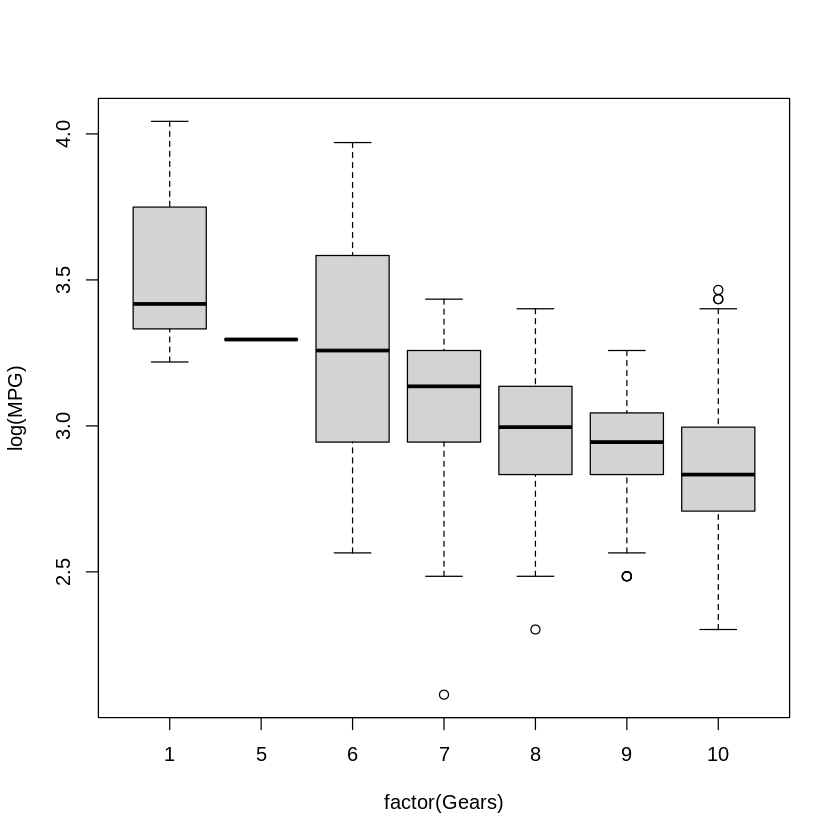

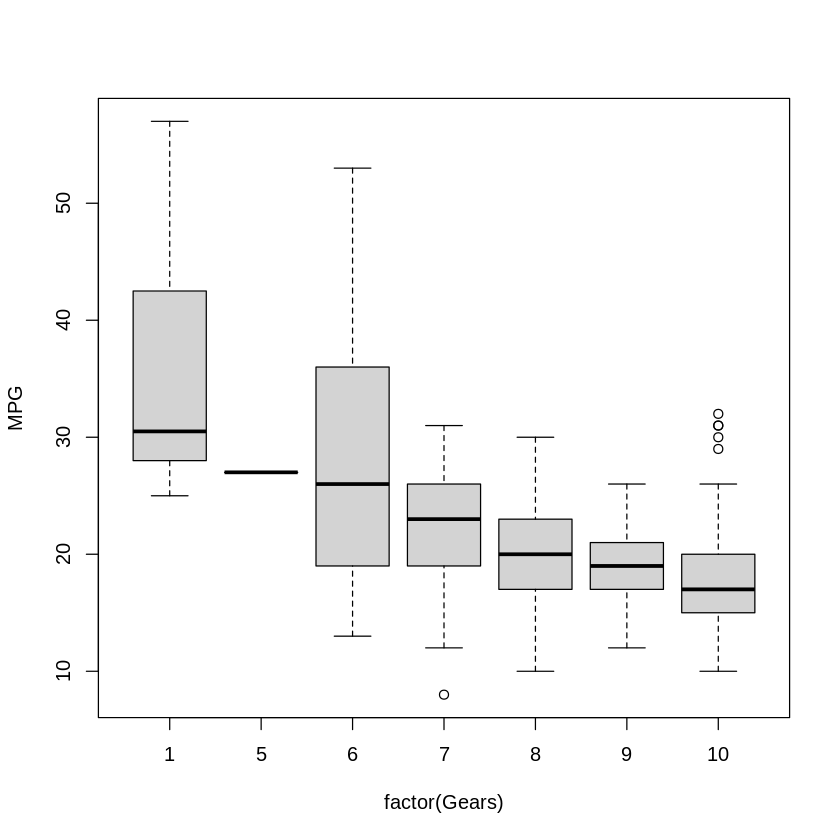

In [ ]:
boxplot(log(MPG)~factor(Gears))
boxplot(MPG~factor(Gears))

In [ ]:
gearsLm <- lm(log(MPG)~Gears)
factorGearsLm <- lm(log(MPG)~factor(Gears))
summary(factorGearsLm)
summary(gearsLm)


Call:
lm(formula = log(MPG) ~ factor(Gears))

Residuals:
     Min       1Q   Median       3Q      Max 
-1.00981 -0.15210  0.01665  0.16325  0.69196 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)      3.53656    0.03027 116.839  < 2e-16 ***
factor(Gears)5  -0.24072    0.23641  -1.018    0.309    
factor(Gears)6  -0.25823    0.03829  -6.744 2.82e-11 ***
factor(Gears)7  -0.44731    0.04213 -10.617  < 2e-16 ***
factor(Gears)8  -0.56053    0.03248 -17.260  < 2e-16 ***
factor(Gears)9  -0.60876    0.03882 -15.680  < 2e-16 ***
factor(Gears)10 -0.67641    0.03571 -18.940  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2345 on 861 degrees of freedom
Multiple R-squared:  0.375,	Adjusted R-squared:  0.3706 
F-statistic: 86.09 on 6 and 861 DF,  p-value: < 2.2e-16



Call:
lm(formula = log(MPG) ~ Gears)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.00772 -0.17248 -0.00954  0.16357  0.80166 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.657446   0.029880  122.41   <2e-16 ***
Gears       -0.081469   0.003752  -21.72   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2379 on 866 degrees of freedom
Multiple R-squared:  0.3526,	Adjusted R-squared:  0.3518 
F-statistic: 471.6 on 1 and 866 DF,  p-value: < 2.2e-16


# Manual Main Effects Model based on exploration

In [ ]:
manualLm <- lm(
  log(MPG) ~ Smog + StartStop + TransmissionType + Drive + Cylinders + factor(Gears),
  data = model_data
)
summary(manualLm)
AIC(manualLm)
BIC(manualLm)


Call:
lm(formula = log(MPG) ~ Smog + StartStop + TransmissionType + 
    Drive + Cylinders + factor(Gears), data = MPGData_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.33754 -0.09054 -0.00736  0.08500  0.54060 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.175832   0.049390  64.301  < 2e-16 ***
Smog               0.027185   0.004715   5.766 1.14e-08 ***
StartStopY         0.085571   0.014009   6.108 1.53e-09 ***
TransmissionTypeM -0.347652   0.030328 -11.463  < 2e-16 ***
DriveA             0.082706   0.015626   5.293 1.53e-07 ***
DriveF             0.168102   0.019005   8.845  < 2e-16 ***
DriveP             0.002156   0.025175   0.086 0.931759    
DriveR             0.065558   0.017221   3.807 0.000151 ***
Cylinders4         0.003027   0.032562   0.093 0.925964    
Cylinders5         0.003862   0.150333   0.026 0.979511    
Cylinders6        -0.162139   0.034139  -4.749 2.39e-06 ***
Cylinders8        -0.342742 

[1] -875.2683

[1] -775.1783

### What is drive P and why is it the only one that's not significant?

P (Performance/Part-time): Sometimes associated with part-time 4WD or specialized performance setups. Part-time systems are typical in trucks, designed to be engaged only on low-traction surfaces, often lacking a center differential, which makes them unsuitable for dry pavement.

# Automatic model selection

In [ ]:
install.packages('leaps')
library(leaps)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Forward

In [ ]:
model_data <- na.omit(MPGData_cleaned[, c(
  "MPG", "Cylinders", "Drive", "TransmissionType", "StartStop", "Smog", "Gears")])

In [ ]:
regfit.fwd.more <- regsubsets(
  log(MPG) ~ .,
  data = model_data,
  nvmax = 19,
  method = "forward"
)
summary(regfit.fwd.more)
reg.summary.more <- summary(regfit.fwd.more)

Subset selection object
Call: regsubsets.formula(log(MPG) ~ ., data = model_data, nvmax = 19, 
    method = "forward")
14 Variables  (and intercept)
                  Forced in Forced out
Cylinders4            FALSE      FALSE
Cylinders5            FALSE      FALSE
Cylinders6            FALSE      FALSE
Cylinders8            FALSE      FALSE
Cylinders12           FALSE      FALSE
Cylinders16           FALSE      FALSE
DriveA                FALSE      FALSE
DriveF                FALSE      FALSE
DriveP                FALSE      FALSE
DriveR                FALSE      FALSE
TransmissionTypeM     FALSE      FALSE
StartStopY            FALSE      FALSE
Smog                  FALSE      FALSE
Gears                 FALSE      FALSE
1 subsets of each size up to 14
Selection Algorithm: forward
          Cylinders4 Cylinders5 Cylinders6 Cylinders8 Cylinders12 Cylinders16
1  ( 1 )  "*"        " "        " "        " "        " "         " "        
2  ( 1 )  "*"        " "        " "        " "   

[1] 10


(Intercept)        Cylinders4        Cylinders6        Cylinders8 
      3.339603888      -0.009525409      -0.183260482      -0.361153014 
      Cylinders12       Cylinders16            DriveF TransmissionTypeM 
     -0.522431189      -0.933273030       0.114154728      -0.157710193 
       StartStopY              Smog             Gears 
      0.068712003       0.026426677      -0.050473713

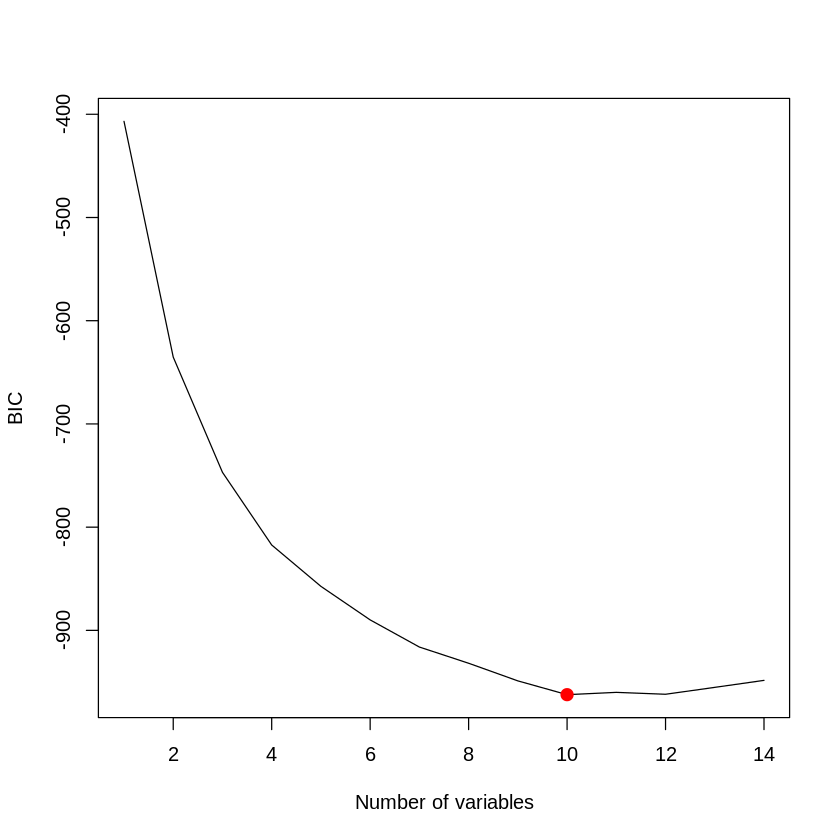

In [ ]:
plot(reg.summary.more$bic, xlab = "Number of variables", ylab = "BIC", type = "l")
min_bic <- which.min(reg.summary.more$bic)
print(min_bic)
points(min_bic, reg.summary.more$bic[min_bic], col = "red", cex = 2, pch = 20)

coef(regfit.fwd.more, min_bic)

## Backward

In [ ]:
regfit.bwd <- regsubsets(
  log(MPG) ~ Cylinders + Drive + TransmissionType + StartStop + Smog + factor(Gears),
  data = model_data,
  nvmax = 19,
  method = "backward"
)
summary(regfit.bwd)
reg.summary <- summary(regfit.bwd)

Subset selection object
Call: regsubsets.formula(log(MPG) ~ Cylinders + Drive + TransmissionType + 
    StartStop + Smog + factor(Gears), data = model_data, nvmax = 19, 
    method = "backward")
19 Variables  (and intercept)
                  Forced in Forced out
Cylinders4            FALSE      FALSE
Cylinders5            FALSE      FALSE
Cylinders6            FALSE      FALSE
Cylinders8            FALSE      FALSE
Cylinders12           FALSE      FALSE
Cylinders16           FALSE      FALSE
DriveA                FALSE      FALSE
DriveF                FALSE      FALSE
DriveP                FALSE      FALSE
DriveR                FALSE      FALSE
TransmissionTypeM     FALSE      FALSE
StartStopY            FALSE      FALSE
Smog                  FALSE      FALSE
factor(Gears)5        FALSE      FALSE
factor(Gears)6        FALSE      FALSE
factor(Gears)7        FALSE      FALSE
factor(Gears)8        FALSE      FALSE
factor(Gears)9        FALSE      FALSE
factor(Gears)10       FALSE      F

[1] 14


(Intercept)        Cylinders6        Cylinders8       Cylinders12 
       3.16962252       -0.16493903       -0.34533351       -0.47082706 
      Cylinders16            DriveA            DriveF            DriveR 
      -0.88710011        0.08249595        0.16968009        0.06473539 
TransmissionTypeM        StartStopY              Smog    factor(Gears)7 
      -0.34763918        0.08483945        0.02761121       -0.31318803 
   factor(Gears)8    factor(Gears)9   factor(Gears)10 
      -0.36781929       -0.41262376       -0.35151138

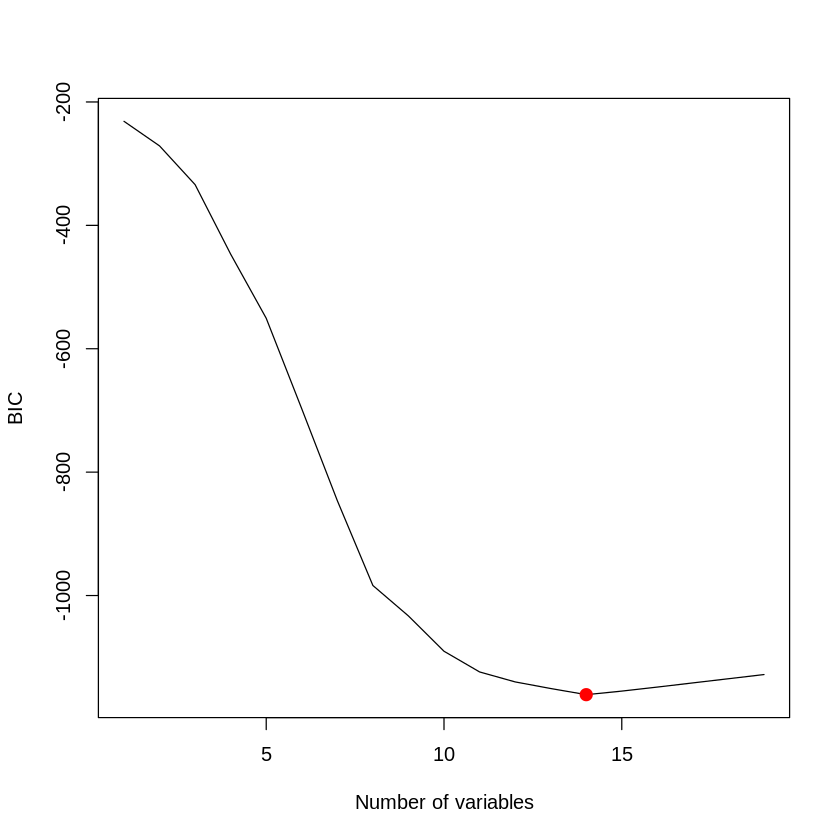

In [ ]:
plot(reg.summary$bic, xlab = "Number of variables", ylab = "BIC", type = "l")
min_bic <- which.min(reg.summary$bic)
print(min_bic)
points(min_bic, reg.summary$bic[min_bic], col = "red", cex = 2, pch = 20)

coef(regfit.bwd, min_bic)

## Best

In [ ]:
regfit.exh <- regsubsets(
  log(MPG) ~ Cylinders + Drive + TransmissionType + StartStop + Smog + factor(Gears),
  data = model_data,
  nvmax = 19
)
summary(regfit.exh)
reg.summary <- summary(regfit.exh)

Subset selection object
Call: regsubsets.formula(log(MPG) ~ Cylinders + Drive + TransmissionType + 
    StartStop + Smog + factor(Gears), data = model_data, nvmax = 19)
19 Variables  (and intercept)
                  Forced in Forced out
Cylinders4            FALSE      FALSE
Cylinders5            FALSE      FALSE
Cylinders6            FALSE      FALSE
Cylinders8            FALSE      FALSE
Cylinders12           FALSE      FALSE
Cylinders16           FALSE      FALSE
DriveA                FALSE      FALSE
DriveF                FALSE      FALSE
DriveP                FALSE      FALSE
DriveR                FALSE      FALSE
TransmissionTypeM     FALSE      FALSE
StartStopY            FALSE      FALSE
Smog                  FALSE      FALSE
factor(Gears)5        FALSE      FALSE
factor(Gears)6        FALSE      FALSE
factor(Gears)7        FALSE      FALSE
factor(Gears)8        FALSE      FALSE
factor(Gears)9        FALSE      FALSE
factor(Gears)10       FALSE      FALSE
1 subsets of each siz

[1] 14


(Intercept)        Cylinders6        Cylinders8       Cylinders12 
       3.16962252       -0.16493903       -0.34533351       -0.47082706 
      Cylinders16            DriveA            DriveF            DriveR 
      -0.88710011        0.08249595        0.16968009        0.06473539 
TransmissionTypeM        StartStopY              Smog    factor(Gears)7 
      -0.34763918        0.08483945        0.02761121       -0.31318803 
   factor(Gears)8    factor(Gears)9   factor(Gears)10 
      -0.36781929       -0.41262376       -0.35151138

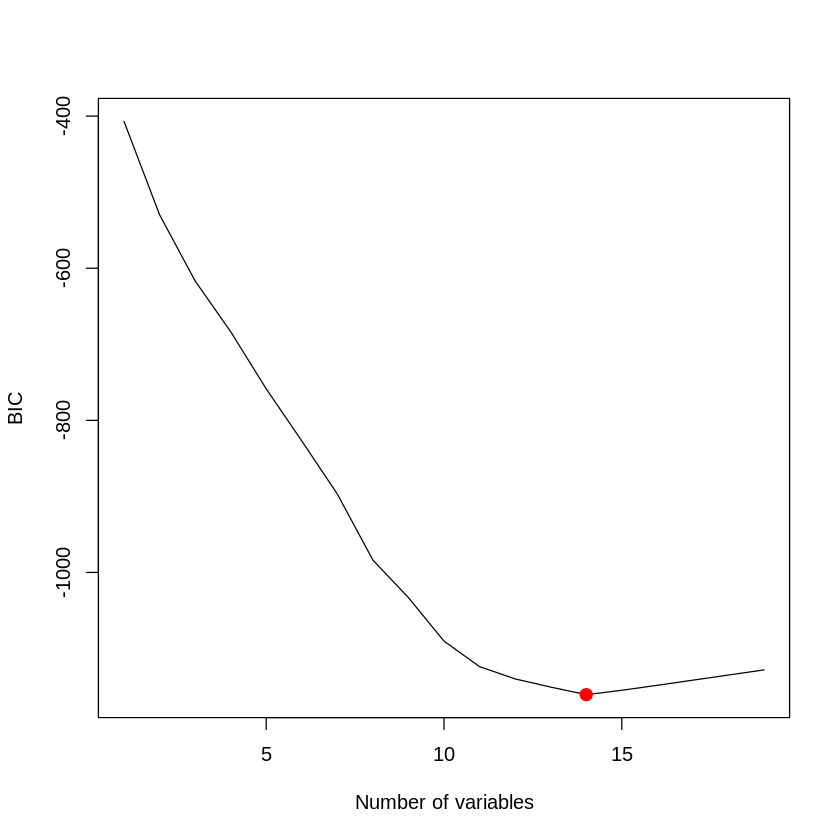

In [ ]:
plot(reg.summary$bic, xlab = "Number of variables", ylab = "BIC", type = "l")
min_bic <- which.min(reg.summary$bic)
print(min_bic)
points(min_bic, reg.summary$bic[min_bic], col = "red", cex = 2, pch = 20)

coef(regfit.exh, min_bic)

# Auto final model

In [ ]:
autoLm <- lm(
  log(MPG) ~ Cylinders + Drive + TransmissionType + StartStop + Smog + factor(Gears),
  data = model_data
)

summary(autoLm)


Call:
lm(formula = log(MPG) ~ Cylinders + Drive + TransmissionType + 
    StartStop + Smog + factor(Gears), data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.33754 -0.09054 -0.00736  0.08500  0.54060 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.175832   0.049390  64.301  < 2e-16 ***
Cylinders4         0.003027   0.032562   0.093 0.925964    
Cylinders5         0.003862   0.150333   0.026 0.979511    
Cylinders6        -0.162139   0.034139  -4.749 2.39e-06 ***
Cylinders8        -0.342742   0.036468  -9.398  < 2e-16 ***
Cylinders12       -0.469133   0.056728  -8.270 5.16e-16 ***
Cylinders16       -0.885244   0.150708  -5.874 6.11e-09 ***
DriveA             0.082706   0.015626   5.293 1.53e-07 ***
DriveF             0.168102   0.019005   8.845  < 2e-16 ***
DriveP             0.002156   0.025175   0.086 0.931759    
DriveR             0.065558   0.017221   3.807 0.000151 ***
TransmissionTypeM -0.347652   0.0

# Interactions

## Automatic selection

In [ ]:
regfit.fwd=regsubsets(log(MPG)~(Cylinders + Drive + TransmissionType + StartStop + Smog)^2,data = model_data, nvmax=19, method ="forward") #backward or forward
summary(regfit.fwd)
reg.summary=summary(regfit.fwd)

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“20  linear dependencies found”


Reordering variables and trying again:


Subset selection object
Call: regsubsets.formula(log(MPG) ~ (Cylinders + Drive + TransmissionType + 
    StartStop + Smog)^2, data = model_data, nvmax = 19, method = "forward")
70 Variables  (and intercept)
                              Forced in Forced out
Cylinders4                        FALSE      FALSE
Cylinders5                        FALSE      FALSE
Cylinders6                        FALSE      FALSE
Cylinders8                        FALSE      FALSE
Cylinders12                       FALSE      FALSE
Cylinders16                       FALSE      FALSE
DriveA                            FALSE      FALSE
DriveF                            FALSE      FALSE
DriveP                            FALSE      FALSE
DriveR                            FALSE      FALSE
TransmissionTypeM                 FALSE      FALSE
StartStopY                        FALSE      FALSE
Smog                              FALSE      FALSE
Cylinders4:DriveA                 FALSE      FALSE
Cylinders6:DriveA           

[1] 11


(Intercept)                    Cylinders4 
                   3.21674654                   -0.06248373 
                   Cylinders6                    Cylinders8 
                  -0.36200328                   -0.57054070 
                  Cylinders12                   Cylinders16 
                  -0.72315266                   -1.11187844 
                       DriveA             Cylinders8:DriveP 
                  -0.02542656                   -0.10255431 
              StartStopY:Smog  Cylinders5:TransmissionTypeM 
                   0.01522694                    0.00000000 
Cylinders12:TransmissionTypeM               Cylinders5:Smog 
                   0.00000000                   -0.09779385

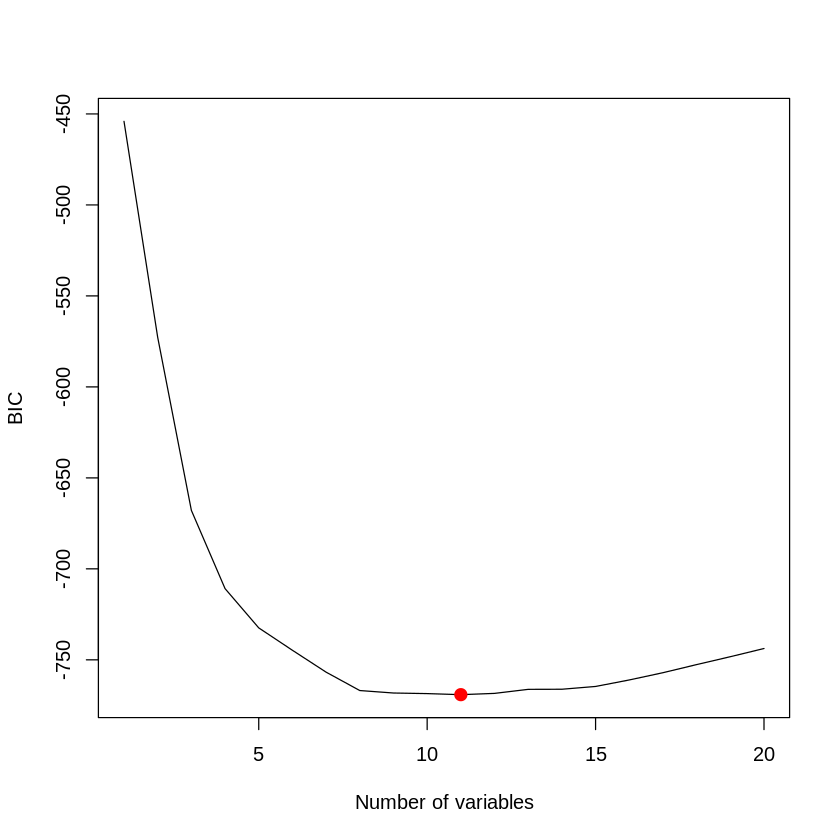

In [ ]:
#We use BIC to select the best model/number of variables
plot(reg.summary$bic, xlab= "Number of variables", ylab = "BIC",type = 'l')
min_bic = which.min(reg.summary$bic ) [1]
print(min_bic) #The number of variables accorind to BIC
points(min_bic,reg.summary$bic [min_bic],col="red",cex=2,pch=20)#The graph shows the minimum value or best model by the BIC
coef(regfit.fwd ,min_bic)

In [ ]:
interactionLm <- lm(log(MPG)~Cylinders + Smog + Drive + Cylinders*Smog + Drive*Smog, data = model_data)
summary(interactionLm)


Call:
lm(formula = log(MPG) ~ Cylinders + Smog + Drive + Cylinders * 
    Smog + Drive * Smog, data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.38997 -0.11118 -0.00790  0.07433  0.83796 

Coefficients: (2 not defined because of singularities)
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       3.243156   0.349832   9.271  < 2e-16 ***
Cylinders4       -0.099832   0.343211  -0.291 0.771217    
Cylinders5       -0.047400   0.286014  -0.166 0.868412    
Cylinders6       -0.120241   0.344536  -0.349 0.727181    
Cylinders8       -0.456433   0.344303  -1.326 0.185305    
Cylinders12      -0.505356   0.374380  -1.350 0.177425    
Cylinders16      -0.915862   0.334503  -2.738 0.006311 ** 
Smog             -0.024416   0.062613  -0.390 0.696670    
DriveA           -0.295681   0.086426  -3.421 0.000653 ***
DriveF           -0.484343   0.137758  -3.516 0.000462 ***
DriveP           -0.585803   0.203159  -2.883 0.004033 ** 
DriveR           

## Manual selection/investigation

In [ ]:
interactionLm2 <- lm(log(MPG)~Cylinders + Drive + StartStop + Smog + factor(Gears) + TransmissionType:factor(Gears), data = model_data)
summary(interactionLm2)


Call:
lm(formula = log(MPG) ~ Cylinders + Drive + StartStop + Smog + 
    factor(Gears) + TransmissionType:factor(Gears), data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.33822 -0.09003 -0.00581  0.08493  0.54694 

Coefficients: (5 not defined because of singularities)
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        3.179389   0.049457  64.286  < 2e-16 ***
Cylinders4                         0.003069   0.032551   0.094 0.924918    
Cylinders5                         0.007119   0.150308   0.047 0.962237    
Cylinders6                        -0.161431   0.034133  -4.730 2.64e-06 ***
Cylinders8                        -0.343307   0.036459  -9.416  < 2e-16 ***
Cylinders12                       -0.470637   0.056723  -8.297 4.18e-16 ***
Cylinders16                       -0.882618   0.150674  -5.858 6.71e-09 ***
DriveA                             0.083250   0.015627   5.327 1.28e-07 ***
DriveF        

In [ ]:
interactionLm3 <- lm(log(MPG)~Cylinders + Drive + StartStop + Smog + factor(Gears) + TransmissionType:Drive, data = model_data)
summary(interactionLm3)


Call:
lm(formula = log(MPG) ~ Cylinders + Drive + StartStop + Smog + 
    factor(Gears) + TransmissionType:Drive, data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.33804 -0.09032 -0.00775  0.08531  0.54471 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)               3.177735   0.050185  63.320  < 2e-16 ***
Cylinders4                0.003168   0.033014   0.096 0.923566    
Cylinders5                0.008324   0.150721   0.055 0.955969    
Cylinders6               -0.159811   0.034675  -4.609 4.68e-06 ***
Cylinders8               -0.342031   0.037004  -9.243  < 2e-16 ***
Cylinders12              -0.467998   0.057231  -8.177 1.06e-15 ***
Cylinders16              -0.880880   0.151105  -5.830 7.91e-09 ***
DriveA                    0.081480   0.015726   5.181 2.76e-07 ***
DriveF                    0.165832   0.019345   8.572  < 2e-16 ***
DriveP                   -0.004719   0.025940  -0.182 0.855680    
DriveR    

# Adding displacement

## Automatic selection

In [ ]:
regfit.exh=regsubsets(log(MPG)~Displacement + Cylinders + Drive + TransmissionType + StartStop + Smog + factor(Gears),data = model_data, nvmax = 25) #backward or forward
summary(regfit.exh)
reg.summary=summary(regfit.exh)

Subset selection object
Call: regsubsets.formula(log(MPG) ~ Displacement + Cylinders + Drive + 
    TransmissionType + StartStop + Smog + factor(Gears), data = model_data, 
    nvmax = 25)
20 Variables  (and intercept)
                  Forced in Forced out
Displacement          FALSE      FALSE
Cylinders4            FALSE      FALSE
Cylinders5            FALSE      FALSE
Cylinders6            FALSE      FALSE
Cylinders8            FALSE      FALSE
Cylinders12           FALSE      FALSE
Cylinders16           FALSE      FALSE
DriveA                FALSE      FALSE
DriveF                FALSE      FALSE
DriveP                FALSE      FALSE
DriveR                FALSE      FALSE
TransmissionTypeM     FALSE      FALSE
StartStopY            FALSE      FALSE
Smog                  FALSE      FALSE
factor(Gears)5        FALSE      FALSE
factor(Gears)6        FALSE      FALSE
factor(Gears)7        FALSE      FALSE
factor(Gears)8        FALSE      FALSE
factor(Gears)9        FALSE      FALSE
f

[1] 12


(Intercept)      Displacement        Cylinders4            DriveA 
       3.28652484       -0.09369486        0.07779926        0.06823249 
           DriveF            DriveR TransmissionTypeM        StartStopY 
       0.14950892        0.06803479       -0.33987298        0.07116687 
             Smog    factor(Gears)7    factor(Gears)8    factor(Gears)9 
       0.03266704       -0.31397347       -0.36067435       -0.41873804 
  factor(Gears)10 
      -0.33163979

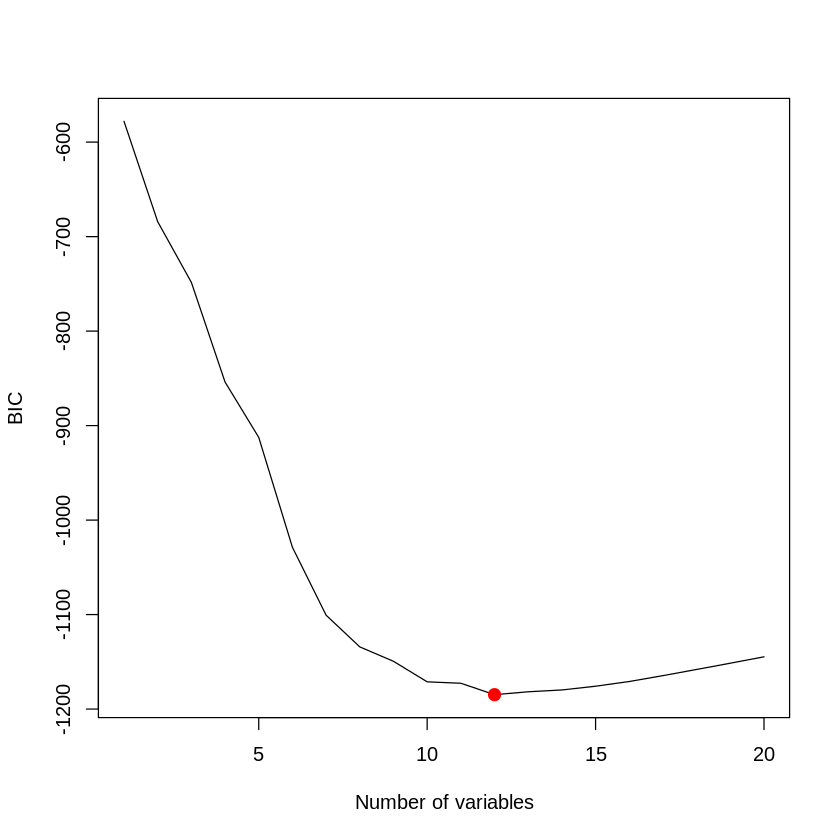

In [ ]:
plot(reg.summary$bic, xlab = "Number of variables", ylab = "BIC", type = "l")
min_bic <- which.min(reg.summary$bic)
print(min_bic)
points(min_bic, reg.summary$bic[min_bic], col = "red", cex = 2, pch = 20)

coef(regfit.exh, min_bic)

In [ ]:
autoLmDisp <- lm(
  log(MPG) ~ Cylinders + Drive + TransmissionType + StartStop + Smog + factor(Gears) + Displacement,
  data = model_data
)

summary(autoLmDisp)


Call:
lm(formula = log(MPG) ~ Cylinders + Drive + TransmissionType + 
    StartStop + Smog + factor(Gears) + Displacement, data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.36324 -0.08684 -0.00557  0.08355  0.54086 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.260223   0.051820  62.914  < 2e-16 ***
Cylinders4         0.046280   0.033380   1.386 0.165974    
Cylinders5         0.071413   0.149073   0.479 0.632031    
Cylinders6        -0.059751   0.039865  -1.499 0.134292    
Cylinders8        -0.140173   0.055416  -2.529 0.011604 *  
Cylinders12       -0.167554   0.084083  -1.993 0.046614 *  
Cylinders16       -0.482356   0.170751  -2.825 0.004841 ** 
DriveA             0.069870   0.015655   4.463 9.17e-06 ***
DriveF             0.151923   0.019061   7.970 5.10e-15 ***
DriveP            -0.009729   0.024975  -0.390 0.696967    
DriveR             0.062976   0.017010   3.702 0.000227 ***
TransmissionTypeM 

## Since we did not include iteraction terms for the stepwise selection, we will try 5 different final models: one without any interactions and four with the most significant interactions found above

In [ ]:
finalLm <- lm(log(MPG)~Displacement + Cylinders + Smog +
  + Drive + TransmissionType + StartStop + factor(Gears) +
  Cylinders*Smog + Drive*Smog,
  data = model_data)
summary(finalLm)


Call:
lm(formula = log(MPG) ~ Displacement + Cylinders + Smog + +Drive + 
    TransmissionType + StartStop + factor(Gears) + Cylinders * 
    Smog + Drive * Smog, data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.36898 -0.09312 -0.00164  0.08433  0.51610 

Coefficients: (2 not defined because of singularities)
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        4.229089   0.273342  15.472  < 2e-16 ***
Displacement      -0.065723   0.012386  -5.306 1.43e-07 ***
Cylinders4        -0.700153   0.265480  -2.637 0.008511 ** 
Cylinders5        -0.310166   0.220917  -1.404 0.160692    
Cylinders6        -0.684448   0.267115  -2.562 0.010570 *  
Cylinders8        -0.820809   0.268832  -3.053 0.002335 ** 
Cylinders12       -0.665886   0.294081  -2.264 0.023811 *  
Cylinders16       -0.944170   0.269900  -3.498 0.000493 ***
Smog              -0.148613   0.048665  -3.054 0.002331 ** 
DriveA            -0.291516   0.069173  -4.214 2.78e-05 *

In [ ]:
finalLm2 <- lm(log(MPG)~Displacement + Cylinders + Smog +
  Drive + TransmissionType + StartStop + factor(Gears) + Cylinders*Smog,
  data = model_data)
summary(finalLm2)


Call:
lm(formula = log(MPG) ~ Displacement + Cylinders + Smog + Drive + 
    TransmissionType + StartStop + factor(Gears) + Cylinders * 
    Smog, data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.36846 -0.09244  0.00025  0.08508  0.53542 

Coefficients: (2 not defined because of singularities)
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.926263   0.270956  14.490  < 2e-16 ***
Displacement      -0.061266   0.012522  -4.893 1.19e-06 ***
Cylinders4        -0.680647   0.269049  -2.530 0.011593 *  
Cylinders5        -0.351418   0.224081  -1.568 0.117195    
Cylinders6        -0.669359   0.270886  -2.471 0.013670 *  
Cylinders8        -0.768764   0.272368  -2.823 0.004877 ** 
Cylinders12       -0.706626   0.297921  -2.372 0.017923 *  
Cylinders16       -1.020149   0.273378  -3.732 0.000203 ***
Smog              -0.089405   0.047964  -1.864 0.062668 .  
DriveA             0.061688   0.015802   3.904 0.000102 ***
DriveF       

In [ ]:
finalLm3 <- lm(log(MPG)~Displacement + Cylinders + Smog +
  Drive + TransmissionType + StartStop + factor(Gears) + Drive*Smog,
  data = model_data)
summary(finalLm3)


Call:
lm(formula = log(MPG) ~ Displacement + Cylinders + Smog + Drive + 
    TransmissionType + StartStop + factor(Gears) + Drive * Smog, 
    data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.36622 -0.09201 -0.00097  0.08203  0.52585 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.527868   0.073868  47.759  < 2e-16 ***
Displacement      -0.064077   0.012443  -5.150 3.25e-07 ***
Cylinders4         0.047298   0.032876   1.439 0.150618    
Cylinders5         0.129185   0.147758   0.874 0.382201    
Cylinders6        -0.046626   0.039414  -1.183 0.237149    
Cylinders8        -0.116484   0.055117  -2.113 0.034860 *  
Cylinders12       -0.119134   0.083583  -1.425 0.154432    
Cylinders16       -0.388755   0.170351  -2.282 0.022733 *  
Smog              -0.022941   0.011312  -2.028 0.042867 *  
DriveA            -0.283605   0.067849  -4.180 3.22e-05 ***
DriveF            -0.115396   0.103382  -1.116 0.264652   

In [ ]:
finalLm4 <- lm(log(MPG)~Displacement + Cylinders + Smog +
  Drive + TransmissionType + StartStop + factor(Gears),
  data = model_data)
summary(finalLm4)


Call:
lm(formula = log(MPG) ~ Displacement + Cylinders + Smog + Drive + 
    TransmissionType + StartStop + factor(Gears), data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.36324 -0.08684 -0.00557  0.08355  0.54086 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.260223   0.051820  62.914  < 2e-16 ***
Displacement      -0.060513   0.012585  -4.808 1.80e-06 ***
Cylinders4         0.046280   0.033380   1.386 0.165974    
Cylinders5         0.071413   0.149073   0.479 0.632031    
Cylinders6        -0.059751   0.039865  -1.499 0.134292    
Cylinders8        -0.140173   0.055416  -2.529 0.011604 *  
Cylinders12       -0.167554   0.084083  -1.993 0.046614 *  
Cylinders16       -0.482356   0.170751  -2.825 0.004841 ** 
Smog               0.029703   0.004684   6.342 3.69e-10 ***
DriveA             0.069870   0.015655   4.463 9.17e-06 ***
DriveF             0.151923   0.019061   7.970 5.10e-15 ***
DriveP            

In [ ]:
finalLm5 <- lm(log(MPG)~Displacement + Smog +
  Drive + TransmissionType + StartStop + factor(Gears) + Drive*Smog,
  data = model_data)
summary(finalLm5)


Call:
lm(formula = log(MPG) ~ Displacement + Smog + Drive + TransmissionType + 
    StartStop + factor(Gears) + Drive * Smog, data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.41223 -0.10222 -0.00768  0.08311  0.53209 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.632959   0.068138  53.318  < 2e-16 ***
Displacement      -0.107178   0.005572 -19.234  < 2e-16 ***
Smog              -0.018222   0.011464  -1.590 0.112313    
DriveA            -0.315247   0.068040  -4.633 4.16e-06 ***
DriveF            -0.103305   0.104971  -0.984 0.325335    
DriveP            -0.550656   0.157905  -3.487 0.000513 ***
DriveR            -0.203581   0.070419  -2.891 0.003938 ** 
TransmissionTypeM -0.344626   0.030266 -11.387  < 2e-16 ***
StartStopY         0.067332   0.013829   4.869 1.34e-06 ***
factor(Gears)5     0.085974   0.147600   0.582 0.560400    
factor(Gears)6     0.007385   0.026305   0.281 0.778962    
factor(Gears)7 

# AIC, BIC, and adjusted R2 for all models

In [ ]:
print("BIC values:")
print(paste("manualLm:", BIC(manualLm)))
print(paste("autoLm:", BIC(autoLm)))
print(paste("interactionLm:", BIC(interactionLm)))
print(paste("interactionLm2:", BIC(interactionLm2)))
print(paste("interactionLm3:", BIC(interactionLm3)))
print(paste("autoLmDisp:", BIC(autoLmDisp)))
print(paste("finalLm:", BIC(finalLm)))
print(paste("finalLm2:", BIC(finalLm2)))
print(paste("finalLm3:", BIC(finalLm3)))
print(paste("finalLm4:", BIC(finalLm4)))
print(paste("finalLm5:", BIC(finalLm5)))

[1] "BIC values:"
[1] "manualLm: -775.178302959003"
[1] "autoLm: -775.178302959003"
[1] "interactionLm: -367.780975544279"
[1] "interactionLm2: -769.993486480835"
[1] "interactionLm3: -750.266529458039"
[1] "autoLmDisp: -791.788237749998"
[1] "finalLm: -782.665698470934"
[1] "finalLm2: -778.852340064194"
[1] "finalLm3: -795.921916520256"
[1] "finalLm4: -791.788237749998"
[1] "finalLm5: -800.185852608241"


In [ ]:
print("\nAIC values:")
print(paste("manualLm:", AIC(manualLm)))
print(paste("autoLm:", AIC(autoLm)))
print(paste("interactionLm:", AIC(interactionLm)))
print(paste("interactionLm2:", AIC(interactionLm2)))
print(paste("interactionLm3:", AIC(interactionLm3)))
print(paste("autoLmDisp:", AIC(autoLmDisp)))
print(paste("finalLm:", AIC(finalLm)))
print(paste("finalLm2:", AIC(finalLm2)))
print(paste("finalLm3:", AIC(finalLm3)))
print(paste("finalLm4:", AIC(finalLm4)))
print(paste("finalLm5:", AIC(finalLm5)))

[1] "\nAIC values:"
[1] "manualLm: -875.26832896687"
[1] "autoLm: -875.26832896687"
[1] "interactionLm: -467.871001552146"
[1] "interactionLm2: -874.849704203363"
[1] "interactionLm3: -869.421322324548"
[1] "autoLmDisp: -896.644455472525"
[1] "finalLm: -925.651449910744"
[1] "finalLm2: -902.773324645363"
[1] "finalLm3: -919.842901101425"
[1] "finalLm4: -896.644455472526"
[1] "finalLm5: -895.509686901448"


In [ ]:
print("\nAdjusted R-squared values:")
print(paste("manualLm:", summary(manualLm)$adj.r.squared))
print(paste("autoLm:", summary(autoLm)$adj.r.squared))
print(paste("interactionLm:", summary(interactionLm)$adj.r.squared))
print(paste("interactionLm2:", summary(interactionLm2)$adj.r.squared))
print(paste("interactionLm3:", summary(interactionLm3)$adj.r.squared))
print(paste("autoLmDisp:", summary(autoLmDisp)$adj.r.squared))
print(paste("finalLm:", summary(finalLm)$adj.r.squared))
print(paste("finalLm2:", summary(finalLm2)$adj.r.squared))
print(paste("finalLm3:", summary(finalLm3)$adj.r.squared))
print(paste("finalLm4:", summary(finalLm4)$adj.r.squared))
print(paste("finalLm5:", summary(finalLm5)$adj.r.squared))

[1] "\nAdjusted R-squared values:"
[1] "manualLm: 0.76150054558169"
[1] "autoLm: 0.76150054558169"
[1] "interactionLm: 0.618649544722873"
[1] "interactionLm2: 0.761653593959836"
[1] "interactionLm3: 0.760963859286637"
[1] "autoLmDisp: 0.767563761921564"
[1] "finalLm: 0.77720444556374"
[1] "finalLm2: 0.770231523001265"
[1] "finalLm3: 0.774705875275889"
[1] "finalLm4: 0.767563761921564"
[1] "finalLm5: 0.766735481321976"


# Exponentiating coefficients

In [ ]:
slopesAutoLm <- autoLm$coefficients
print(exp(slopesAutoLm))

      (Intercept)        Cylinders4        Cylinders5        Cylinders6 
       23.9467338         1.0030312         1.0038694         0.8503227 
       Cylinders8       Cylinders12       Cylinders16            DriveA 
        0.7098215         0.6255444         0.4126134         1.0862220 
           DriveF            DriveP            DriveR TransmissionTypeM 
        1.1830571         1.0021587         1.0677542         0.7063448 
       StartStopY              Smog    factor(Gears)5    factor(Gears)6 
        1.0893393         1.0275574         1.1427310         0.9877528 
   factor(Gears)7    factor(Gears)8    factor(Gears)9   factor(Gears)10 
        0.7253969         0.6869974         0.6569406         0.6979816 


# Which model to choose?
While finalLm is technically the best model based on both AIC and BIC, it's only marginally better than finalLm3 which is a simpler model that is easier to interperet. For this reason, I believe we should go with the final model 3.

Warning message:
“not plotting observations with leverage one:
  684”


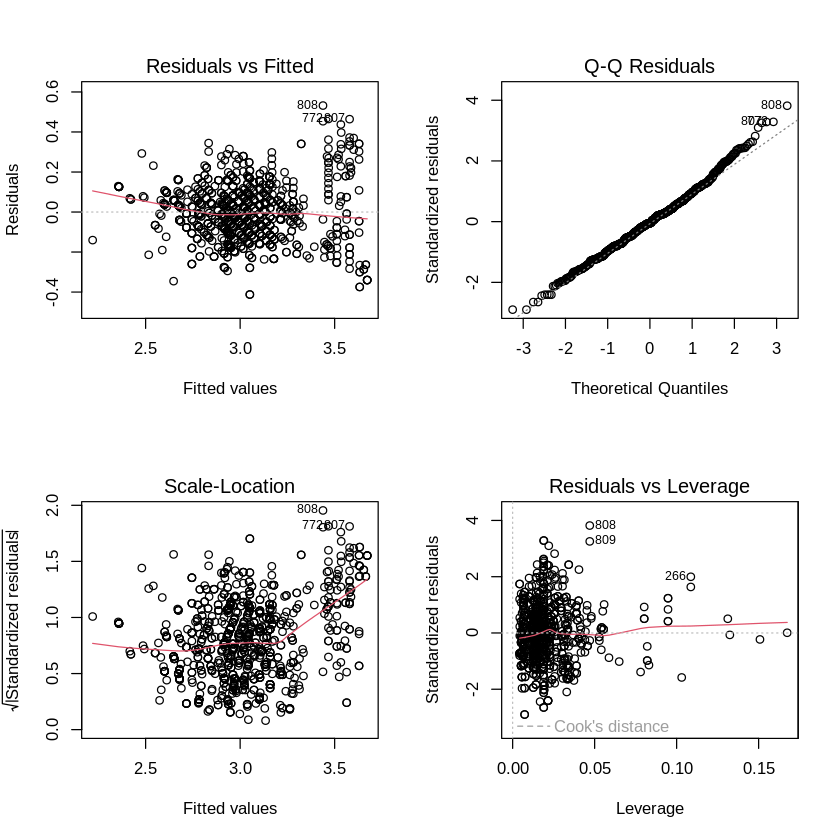

In [ ]:
par(mfrow = c(2,2))
plot(finalLm5)
par(mfrow = c(1,1))

In [ ]:
shapiro.test(resid(finalLm5))


	Shapiro-Wilk normality test

data:  resid(finalLm5)
W = 0.99384, p-value = 0.001245


# Predictions for our specific cars

## Amy's car:
2016 Hyundai Veloster, 4 cylinders, drive F, transmission manual m6, start/stop n, smog 5, gears 6, displacement 1.6, aspiration na, intake valves 2, exhaust valves 2, valve timing y, valve lift n, cylinder deactivation n, car class 4, vehicle category car, torque converter n, creeper gear n, FE rating 7, GHG rating 7, oil viscocity 5W-20 AIP SM or ILSAC GF4
## Brenna's car:
2018 Hyundai Sonata, 4 cylinders, drive F, transmission automatic s6,
start/stop n, smog 5, gears 6, displacement 2.4, aspiration Naturally Aspirated, intake valves 2, exhaust valves 2, valve timing y, valve lift n, cylinder deactivation n, car class 6, vehicle category car, torque converter y, creeper gear n, FE ratin 6, GHG 6, oil viscosity 5W-20

## James's car:


In [ ]:
levels(MPGData_cleaned$Drive)
levels(MPGData_cleaned$TransmissionType)
levels(MPGData_cleaned$StartStop)
levels(MPGData_cleaned$StartStop)

[1] "4" "A" "F" "P" "R"

[1] "A" "M"

[1] "N" "Y"

[1] "N" "Y"

In [ ]:
(MPGData_cleaned$Displacement)
levels(as.factor(MPGData_cleaned$Cylinders)) # Convert to factor to see levels
MPGData_cleaned$Smog
levels(MPGData_cleaned$Drive)
levels(MPGData_cleaned$TransmissionType)
levels(MPGData_cleaned$StartStop)
(MPGData_cleaned$Gears)

[1] 1.5 1.5 1.5 2.0 1.5 1.5 3.5 3.0 3.5 2.0 2.0 2.0 2.0 3.0 2.0 2.0 2.0 2.0
 [19] 4.0 4.0 5.2 4.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 3.0 2.0 3.0 3.0 3.0 2.0 2.0
 [37] 2.0 2.0 2.0 2.0 2.0 2.0 3.0 3.0 2.5 2.9 4.0 4.0 4.0 2.0 3.0 3.0 3.0 2.9
 [55] 2.9 4.0 3.0 3.0 3.0 3.0 4.0 4.0 4.0 4.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0
 [73] 2.0 2.0 2.0 2.0 2.0 3.0 3.0 3.0 4.4 3.0 3.0 3.0 3.0 3.0 3.0 4.4 3.0 3.0
 [91] 2.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0 3.0
[109] 3.0 4.4 4.4 4.4 4.4 4.4 4.4 2.0 2.0 2.0 2.0 3.0 2.0 3.0 3.0 3.0 2.0 4.4
[127] 4.4 3.0 3.0 4.4 4.4 3.0 4.4 3.0 3.0 3.0 2.0 8.0 2.5 2.5 1.3 1.3 1.2 2.0
[145] 1.2 1.2 2.7 2.0 2.7 2.7 3.6 3.6 2.7 3.0 2.0 3.0 2.0 3.0 6.2 6.2 3.0 6.2
[163] 6.2 6.2 2.0 2.0 2.0 3.6 2.0 3.6 2.0 3.6 2.0 3.6 2.0 3.6 2.0 3.6 2.7 2.7
[181] 2.7 2.7 2.7 6.2 6.2 5.5 5.5 5.5 1.5 1.5 1.5 3.0 2.7 2.7 5.3 5.3 5.3 3.0
[199] 3.0 2.7 2.7 5.3 6.2 5.3 5.3 5.3 5.3 3.0 3.0 2.7 2.7 5.3 6.2 5.3 5.3 5.3
[217] 3.0 6.2 6.2 5.3 3.0 6.2 5.3 3.0 6.2 5.3 3.0 6.2 5.3 5.3 3.0 1.3 1.3 1.2
[235] 2.5 2.5 1.2 1.2 3.6 3.6 3.6 3.6 5.7 3.6 5.7 6.2 2.0 6.5 6.5 3.9 2.3 2.7
[253] 2.3 2.7 2.3 2.3 2.7 3.0 2.3 2.3 1.5 2.0 1.5 2.0 1.5 2.5 1.5 2.5 3.5 3.5
[271] 3.0 3.0 2.3 3.0 3.0 2.3 3.5 2.7 5.0 3.5 2.7 5.0 3.5 3.5 5.0 3.5 5.2 2.0
[289] 2.5 2.5 2.0 2.0 5.0 2.3 5.0 5.0 5.0 5.2 2.3 2.3 2.7 3.0 3.3 2.5 3.3 2.5
[307] 2.5 3.5 3.5 3.5 2.5 2.5 3.5 2.5 3.5 3.5 2.5 2.5 2.7 2.7 2.7 2.7 3.0 2.7
[325] 2.7 5.3 5.3 5.3 3.0 2.7 2.7 5.3 6.2 5.3 5.3 5.3 3.0 6.2 5.3 3.0 2.7 5.3
[343] 6.2 5.3 5.3 5.3 1.5 1.5 6.2 5.3 3.0 6.2 5.3 3.0 6.2 5.3 3.0 6.2 5.3 3.0
[361] 1.5 2.0 2.0 1.5 2.0 2.0 2.0 2.0 2.0 2.0 1.5 2.0 1.5 2.0 2.0 2.0 3.5 3.5
[379] 3.5 3.5 3.5 3.5 3.5 3.5 2.0 2.0 1.6 1.6 1.6 2.0 2.0 1.6 2.0 2.0 1.6 2.0
[397] 2.0 3.8 3.8 2.5 2.5 2.5 2.5 2.5 2.5 2.5 1.6 1.6 2.5 2.5 2.5 2.5 2.0 2.5
[415] 2.5 1.6 1.6 1.6 3.0 3.0 2.0 2.0 2.0 2.0 3.5 3.5 2.0 3.0 5.0 2.0 3.6 3.6
[433] 3.6 3.6 3.6 3.0 3.0 3.0 3.0 3.0 3.0 2.0 3.6 2.0 3.6 3.6 6.4 3.5 1.6 2.0
[451] 2.0 1.6 2.5 2.5 2.5 2.5 1.6 1.6 1.6 2.0 2.0 2.5 2.5 2.5 2.5 1.6 1.6 2.0
[469] 2.0 2.5 2.5 1.6 1.6 2.5 3.8 3.8 2.0 5.0 4.4 5.0 3.0 3.0 3.0 2.0 5.0 3.0
[487] 2.0 2.0 2.0 4.4 4.4 3.0 3.0 4.4 3.0 3.0 4.4 4.4 4.4 2.0 3.0 3.0 2.5 2.5
[505] 3.5 3.5 3.4 2.0 3.5 3.5 3.5 5.0 5.0 5.0 3.5 3.4 3.4 3.5 3.5 3.4 3.4 2.5
[523] 2.5 2.4 2.4 2.5 2.0 3.5 3.5 3.5 5.0 2.4 2.4 2.5 2.4 2.4 2.4 2.4 2.0 2.0
[541] 2.0 2.0 3.0 3.0 2.0 2.0 2.0 2.0 3.5 3.5 3.5 3.0 3.0 3.0 3.0 2.0 2.0 3.0
[559] 3.0 3.0 3.0 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 2.5 3.3 3.3 3.3 3.3 2.5 2.5
[577] 2.5 2.5 2.5 2.5 2.5 2.0 2.0 2.0 2.0 2.0 3.0 3.0 4.0 2.0 2.0 2.0 2.0 3.0
[595] 3.0 4.0 4.0 4.0 2.0 3.0 3.0 4.0 4.0 4.0 4.0 2.0 4.0 4.0 2.0 2.0 2.0 2.0
[613] 2.0 2.0 3.0 3.0 2.0 2.0 3.0 3.0 3.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0
[631] 3.0 3.0 4.0 3.0 4.0 4.0 3.0 4.0 4.0 6.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0
[649] 2.0 2.0 2.5 2.5 1.5 1.5 1.5 2.0 2.4 2.5 2.5 2.5 3.5 3.5 3.5 3.8 3.8 3.8
[667] 2.0 2.0 1.6 2.0 2.0 3.5 3.5 3.5 3.5 1.5 1.5 1.5 1.5 1.5 2.0 2.0 1.6 1.6
[685] 3.0 3.0 3.0 2.0 2.0 4.0 4.0 2.5 2.5 2.0 2.0 4.0 4.0 2.5 2.5 4.0 4.0 3.0
[703] 3.6 3.6 3.0 3.6 3.6 3.6 3.0 3.0 3.0 3.0 3.6 3.7 3.7 3.7 3.7 3.0 3.0 4.0
[721] 4.0 4.0 4.0 4.0 2.0 2.9 2.9 2.0 2.9 2.9 4.0 3.0 3.6 3.0 3.6 3.6 3.0 3.0
[739] 6.7 6.7 6.7 6.7 6.7 6.7 6.7 2.4 2.4 2.4 2.4 2.0 2.5 2.5 2.5 2.5 2.5 2.5
[757] 2.0 2.5 2.5 2.4 2.5 2.4 2.4 2.4 2.4 2.4 2.4 2.4 2.4 2.4 2.4 2.5 2.5 2.5
[775] 2.5 2.5 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 2.0 1.8 1.8 1.8 1.8 1.6 1.6 2.4
[793] 2.4 2.4 2.4 2.5 2.5 2.4 2.4 2.4 2.4 2.4 2.4 2.5 2.5 2.4 2.0 2.0 2.0 2.0
[811] 2.5 2.5 2.5 2.5 2.5 2.5 3.4 3.4 2.5 2.5 2.0 3.0 3.0 2.4 2.4 2.4 2.4 2.4
[829] 2.4 2.4 2.4 2.4 2.4 2.5 2.4 2.5 3.4 3.4 3.4 3.4 3.4 3.4 3.4 2.0 2.0 2.0
[847] 2.0 2.0 2.0 2.0 2.0 2.0 2.0 1.5 1.5 1.5 1.5 2.0 2.0 2.0 2.0 2.0 2.0 2.0
[865] 2.0 2.0 2.0 2.0

[1] "3"  "4"  "5"  "6"  "8"  "12" "16"

[1] 5 5 6 5 6 5 4 4 4 5 5 6 6 4 4 4 4 6 5 5 2 5 6 4 4 4 4 4 4 4 4 4 4 4 5 6 4
 [38] 4 4 6 6 4 4 4 2 4 2 2 3 4 4 4 4 4 4 2 4 4 4 4 2 2 2 2 7 2 2 7 7 7 7 7 7 7
 [75] 7 6 6 6 6 6 4 2 2 2 2 2 2 2 4 4 5 4 4 4 4 4 6 6 4 4 4 4 6 6 6 6 6 6 4 2 2
[112] 2 2 2 2 5 7 5 7 6 7 2 2 4 6 4 4 6 6 4 4 6 4 6 4 4 6 1 5 5 6 6 6 6 6 6 5 6
[149] 5 5 4 4 5 4 6 4 6 4 2 2 4 5 5 2 6 6 6 5 6 5 6 5 6 5 6 5 6 5 6 6 6 6 6 4 2
[186] 2 2 2 6 6 6 4 6 6 6 6 6 4 4 6 6 4 5 6 6 6 6 4 4 6 6 4 5 6 6 6 4 5 5 6 4 5
[223] 6 4 5 6 4 5 6 6 4 6 6 6 5 5 6 6 6 6 6 6 4 6 4 1 6 5 2 5 6 5 6 5 6 6 5 5 6
[260] 6 6 6 6 6 6 7 6 7 6 6 5 5 6 5 5 6 6 6 5 6 6 5 6 6 5 6 4 6 7 7 6 6 4 6 4 4
[297] 4 4 6 6 5 5 4 5 4 5 6 5 4 4 4 4 4 6 5 5 5 5 6 6 6 6 4 6 6 6 6 6 4 6 6 4 5
[334] 6 6 6 4 5 6 4 6 4 5 6 6 6 6 6 5 6 4 5 6 4 5 6 4 5 6 4 6 6 6 5 6 6 6 6 6 5
[371] 5 6 6 6 6 6 4 4 6 6 6 6 4 4 6 6 4 6 6 2 2 6 6 6 6 6 6 5 5 6 6 6 6 6 6 6 6
[408] 6 6 6 6 4 6 6 6 6 6 4 6 6 5 5 5 5 5 5 6 6 2 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
[445] 6 6 1 5 6 6 6 6 6 6 4 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 5 5 6 2 5 2 6
[482] 6 6 6 2 6 6 6 6 5 5 6 6 5 6 6 5 5 5 6 6 6 5 6 4 4 4 4 4 4 4 4 4 4 6 4 4 6
[519] 6 4 4 5 5 6 6 6 4 4 4 4 4 6 6 6 6 6 6 6 6 6 6 6 5 5 6 6 6 6 6 2 2 4 4 4 4
[556] 4 4 4 5 4 4 6 4 6 6 4 6 4 6 6 5 5 5 5 6 6 4 6 6 6 4 2 2 4 5 2 6 6 2 5 6 5
[593] 4 6 6 4 4 4 4 5 5 4 4 4 4 4 4 4 7 7 6 6 7 7 7 7 7 7 7 7 6 6 6 6 6 6 6 6 6
[630] 6 6 6 4 6 4 4 7 4 4 2 6 6 6 6 6 6 6 7 5 7 5 5 4 4 4 4 4 6 6 6 5 5 5 5 5 5
[667] 6 6 6 5 5 4 4 4 4 5 5 5 5 5 6 6 6 6 4 4 4 1 1 4 4 1 1 1 1 4 4 1 1 2 2 4 5
[704] 5 4 5 5 5 4 4 4 4 5 4 4 5 4 4 4 4 4 4 4 2 4 4 4 4 5 5 4 6 6 6 6 6 6 6 2 2
[741] 2 2 2 2 2 4 4 2 2 6 6 6 6 7 6 6 6 6 6 5 6 5 5 2 2 6 6 6 6 6 6 6 6 6 6 6 6
[778] 6 6 6 6 6 6 6 6 6 6 6 6 4 4 2 2 6 6 6 6 6 6 6 6 6 6 6 6 5 6 6 6 6 6 5 5 5
[815] 6 6 4 4 6 6 6 4 4 6 6 4 6 6 6 6 6 6 6 6 6 6 4 4 4 4 4 4 4 4 4 4 4 4 4 6 6
[852] 4 4 6 6 7 7 6 6 6 4 4 6 6 4 6 6 6

[1] "4" "A" "F" "P" "R"

[1] "A" "M"

[1] "N" "Y"

[1]  7  7  7  6  7  6 10 10 10 10 10 10 10 10  8  8  8  9  8  9  8  8  7  7  7
 [26]  7  7  7  7  7  7  7  7  8  8  8  7  7  7  7  7  8  8  8  7  8  8  8  8  7
 [51]  8  7  8  8  8  8  8  7  8  7  8  8  8  8  7  8  8  8  8  8  8  8  8  8  8
 [76]  8  8  8  8  8  8  8  8  8  8  8  8  8  6  8  7  8  8  8  8  6  8  8  8  8
[101]  6  8  8  8  8  8  8  8  8  8  8  8  8  8  8  7  7  7  7  8  8  8  8  8  8
[126]  8  8  8  8  8  8  8  8  8  8  6  8  7  8  8  9  1  1  9  6  6 10  8 10 10
[151] 10  6 10 10 10 10 10 10 10  6 10 10 10 10  9  9  9  9  9  9  9  9  9  9  9
[176]  9  9  9  8  8  8  8  8  8  8  8  8  8  8  1  1 10  8  8 10 10 10 10 10  8
[201]  8 10 10 10 10 10 10 10 10  8  8 10 10 10 10 10 10 10 10 10 10 10 10 10 10
[226] 10 10 10 10 10 10  9  1  1  8  8  6  6  9  9  9  8  8  8  8  8  9  8  7  8
[251] 10 10  7 10 10  7 10 10 10  7  8  8  8  8  8  1  8  1 10 10 10 10 10 10 10
[276] 10 10 10 10 10 10 10 10 10 10 10 10  8  1  1  8  8 10 10  6 10  6  8 10 10
[301] 10 10  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8 10  8  8
[326] 10 10 10 10  8  8 10 10 10 10 10 10 10 10 10  8 10 10 10 10 10  8  1 10 10
[351] 10 10 10 10 10 10 10 10 10 10  1  1  1  6  1  7  1  7  1  6  1  1  1  1  1
[376]  1 10  9 10 10 10 10  9  9  1  1  7  6  6  8  6  8  1  1  8  1  1  8  8  8
[401]  8  8  8  8  8  8  6  6  8  8  8  8  6  8  8  6  6  1  8  8  8  8  9  9  9
[426]  9  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  6  8  8  6  8  8  6  1
[451]  1  8  8  8  8  8  6  6  8  8  8  8  8  8  8  6  6  1  1  8  8  6  6  8  8
[476]  8  8  8  8  8  8  8  8  8  8  8  8  9  9  8  8  8  8  8  8  8  8  8  8  8
[501]  8  8  8  6  8  8 10  8  6  8  6  8 10 10 10 10 10 10 10 10 10  8  8  8  8
[526]  6  8  6  8  6  8  8  8  6  6  8  8  6  6  1  6  1 10 10  8  8  8  1 10  6
[551]  6  8  8  8  8  8  8  8  8  8  8  6  6  6  6  6  6  6  1  1  8  8  8  8  6
[576]  6  6  6  6  6  6  6  6  9  8  8  9  9  9  8  8  9  9  9  9  9  9  9  9  9
[601]  9  9  9  9  9  9  9  9  9  9  8  8  9  9  9  9  9  9  9  9  9  8  8  8  8
[626]  9  9  9  9  9  9  9  9  9  9  9  9  9  9  9  7  7  7  7  7  7  7  7  7  7
[651]  8  8  8  8  8  6  6  1  1  1  9  9  9  9  9  9  1  1  1  9  9  9  9  9  9
[676]  8  8  8  8  8  1  1  1  5  6  9  9  6  7  6  7  6  7  6  7  6  7  6  7  7
[701]  7  8  8  8  8  8  8  8  8  8  6  6  8  8  8  8  8  8  8  8  8  8  8  8  7
[726]  7  7  7  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  6  6  8
[751]  8  8  8  6  8  8  8  8  8  8  8  8  8  6  8  8  8  8  8  8  8  6  6  6  6
[776]  6  1  1 10 10 10  6  1 10 10  1  1  1  1  8  6  6  6  8  8  6  6  6  8  8
[801]  8  8  8  6  6  8  1  1  1  1  8  8  8  8  6  6 10 10  6  6  8  8  6  8  8
[826]  6  8  8  8  8  8  8  8  1  6  6 10 10 10 10 10 10 10  8  8  8  8  8  8  7
[851]  6  7  7  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8

In [ ]:
team_cars <- data.frame(
  Name = c("Amy", "Brenna", "James"),
  Displacement = c(1.6, 2.0, 3.5),
  #Cylinders = factor(c(4, 4, 6), levels = levels(MPGData_cleaned$Cylinders)),
  Drive = factor(c("F", "A", "F"), levels = levels(MPGData_cleaned$Drive)),
  TransmissionType = factor(c("M", "A", "A"), levels = levels(MPGData_cleaned$TransmissionType)),
  StartStop = factor(c("N", "Y", "N"), levels = levels(MPGData_cleaned$StartStop)),
  Smog = c(5, 6, 6),
  Gears = factor(c(6, 6, 5), levels = levels(factor(MPGData_cleaned$Gears)))
)

# Redefine finalLm3 to use column names directly
#finalLm3_corrected <- lm(log(MPG)~Displacement + Cylinders + Smog + Drive + TransmissionType + StartStop + factor(Gears) + Drive*Smog, data = MPGData_cleaned)
finalLm5_corrected <- lm(log(MPG)~Displacement + Smog + Drive + TransmissionType + StartStop + factor(Gears) + Drive*Smog, data = MPGData_cleaned)

team_cars$PredictedLogMPG <- predict(finalLm5_corrected, newdata = team_cars)
team_cars$PredictedMPG <- exp(team_cars$PredictedLogMPG)

team_cars

Name,Displacement,Drive,TransmissionType,StartStop,Smog,Gears,PredictedLogMPG,PredictedMPG
<chr>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>,<dbl>
Amy,1.6,F,M,N,5,6,3.184529,24.15590
Brenna,2.0,A,A,Y,6,6,3.520646,33.80624
James,3.5,F,A,N,6,5,3.436825,31.08809


In [ ]:
install.packages("lawstat")
library(lawstat)

levene.test(residuals(finalLm3_corrected), group = MPGData_cleaned$Displacement)

# Shapiro-Wilk Test for normality of residuals
shapiro.test(MPGData_cleaned$Displacement)


levene.test(residuals(finalLm3_corrected), group = log(MPGData_cleaned$Displacement))

# Shapiro-Wilk Test for normality of log(Displacement)
shapiro.test(log(MPGData_cleaned$Displacement))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  residuals(finalLm3_corrected)
Test Statistic = 4.1738, p-value = 8.439e-13



	Shapiro-Wilk normality test

data:  MPGData_cleaned$Displacement
W = 0.87598, p-value < 2.2e-16



	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  residuals(finalLm3_corrected)
Test Statistic = 4.1738, p-value = 8.439e-13



	Shapiro-Wilk normality test

data:  log(MPGData_cleaned$Displacement)
W = 0.96138, p-value = 2.293e-14


In [ ]:
levene.test(residuals(finalLm3_corrected), group = MPGData_cleaned$Cylinders)

# Shapiro-Wilk Test for normality of residuals
shapiro.test(residuals(finalLm3_corrected))


	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  residuals(finalLm3_corrected)
Test Statistic = 9.1716, p-value = 9.453e-10



	Shapiro-Wilk normality test

data:  residuals(finalLm3_corrected)
W = 0.99214, p-value = 0.0001443


In [ ]:
shapiro.test(residuals(finalLm5))

ERROR: Error: object 'finalLm5' not found
